In [1]:
import numpy as np
import scipy.linalg as LA
import matplotlib.pyplot as plt
import cvxpy as cp
import copy
import time
import warnings
import scipy.optimize as opt
from scipy.linalg import solve_discrete_lyapunov, sqrtm
from joblib import Parallel, delayed

# Online Linear Control with Non-convex Costs and Feed-forward update in inner loop.

We are now interested in creating simulations for the journal version of the paper submitted to CDC 2026. The major additions and subtractions compared to the simulation code used therein is as follows:

###  Additions
1. **Non-convex oracles**: The previous notebook only considered convex, and in particular, convex quadratic costs. In this notebook, we will begin considering some highly structured non-convex costs. The advantage of our theoritical analysis is that it is agnostic to the convexity of the incoming cost. So the same regret bounds carry forward. But ofcourse, the computation can be very unwieldy for general non-convex costs. So we considered more strucutred ones.   

2. **Restriction to quadratic costs**: Following up the previous point, by "structured" costs we consider ones that are complications of quadratic costs. For instance, one will capture a cost fucntion that can be described as minimum of two quadratic costs functions. The goal is not to minimize the $\sum_t \min{f_1^t(x), f_2^t(x)}$ (which is actually what the previous function suggests perhaps ) but rather $\min{\sum_t f_1^t, \sum_t f_2^t}$ where both $f_1^t,f_2^t$ are convex quadratic for all $t$. The idea this captures is try and track one of two targets the whole time, but which one to track depends on the which minimizes the cost in hindsight. Alternately, we will consider control under non-convex constraints.  

3. **Addition of $v$ update in the inner loop**: This is the most important thing I am interested in. We will first test out one approach empirically to see if this algorithm improves performance over the previous one, and then try to obtain the pertinent regret bound.

### Subtractions

1. **No DAC benchmark**: Importantly we will no longer consider either the DAC benchmark or the DAC approach as a comparison point. This is becaus, one, the performance advantage has already been established in the previously run simulations and two, because it will no longer be applicable once we move to non-convex cost functions.  

2. **CVXPY based oracle for FTPL**: Because we are working with costs with some quadratic form for the most part, whenever possible we will avoid using CVPY QP solver and instead try to employ closed form expression for solutions whenever possible. Reason being ofcourse the computational speed up. Our goal is to run large time horizon and large number of trials with the limited compute I have available to me.    

### Notebook Layout/Blue-print

1. First, we implement the closed form solver for a quadratic program being optimized over an ellipsoid. We compare the performance improvement w.r.t to the compute performance achieved in the other notebook which employed CVXPY. (That is the true benchmark to compare the compute performance of DAC vs BatchFTPL, but we no longer care to compare so it does not matter if we exploit additional structure in our problem.) 

2. Second, we introduce the inner loop that picks $v$ while keeping $K$ fixed in each batch of the bathFTPL run. Once again, we compare performance to the method implemented in the CDC 2026 submission/previous notebook which does not vary $v$ in this inner loop.

3. Third, we will try to find two distinct examples on online control with non-convexities: either constraints on input set or non-convxe cost functions themselves. To be thought about mroe in the future.   

### Defining the LTI system and computing the set of stabilizing controllers.

We will work with the following system $$A = \frac{1}{3.6}\begin{bmatrix}
    1 & 0.2 & 0 \\
    0 &  1 &  0.2 \\
    0.2 & 0 & 1 \\
\end{bmatrix} \text{ and } B = \begin{bmatrix}
    0 & 1 \\
    0 & 0 \\
    1 & 0
\end{bmatrix}.$$
And assume that the cost functions are quadratic of the form $$ f_t(x_t) = (x-c_t)^T Q_t (x-c_t)$$ for all time where $Q_t$ and $c_t$ will be randomly generated in some manner. We will assume that there are disturbances $w_t$ acting on the system. This is necessary because we need it to implement DAC based approaches.  

In [2]:
#### No change from the Affine Benchmark notebook. 
# Defining our system 
DIM_X = 3  # State dimension
DIM_U = 2  # Control dimension

# Define initial state. While this can be set to anything we will set it to zero. Some of the benchmarks are easier to compute with if we do this.
x0 = np.zeros(DIM_X) 

# Generate stable A matrix
A = 2/3*np.array([[1,0.2,0.0]
              ,[0,1,0.2],
              [0.2,0,1]])

print('Spectral Radius of A:',np.max(np.abs(np.linalg.eigvals(A)))) # Check that the spectral radius is less than 1

# Generate control matrix B
B = np.array([[0,1.0],
              [0,0],
              [1,0]])

# Computing the Moore-Penrose inverse for B. Not sure I need this!
B_inv = np.linalg.inv(B.T @ B) @ B.T

# Feedforward input and disturbance bound 
U = 3.0
W = 0.2


Spectral Radius of A: 0.7999999999999999


### Set of strongly stabilizing matrices.
We will also establish the set of strongly $(\kappa, \gamma)$-stabilizing matrices $\mathcal{K}$. In particular we will approximate his set by using a finite number ($N_K=100$) different matrices that lie inside this set. To this end we will generate 100 different positive definite $Q$ and $R$ matrices and treating them as LQR cost matrices we will use the DARE to generate 100 different stabilizing matrices (here we are using the fact that optimal LQR controllers are stabilizing).

In [3]:
### Change from the Affine Benchmark notebook.
# Remove function to compute H for DAC. 
def schur_stable_decomposition(M):
    """
    Given a Schur-stable matrix M (spectral radius < 1), returns (gamma, kappa) such that
      M = H^{-1} J H,  |J| <= (1 - gamma),  |H||H^{-1}|_2 <= kappa.
 
    Solves the discrete Lyapunov equation M^T P M - P = -I for P, sets H = sqrtm(P), and J = H M H^{-1},
    and returns gamma = 1 - |J|  and  kappa = |H||H^{-1}|.
    """
    # Check if the matrix is Schur-stable before attempting the decomposition
    rho = np.max(np.abs(np.linalg.eigvals(M)))
    if rho >= 1.0:
        raise ValueError(f"Matrix is not Schur-stable (spectral radius = {rho:.6f}).")
 
    # Solve the discrete Lyapunov equation M^T P M - P = -I for P
    P     = solve_discrete_lyapunov(M.T, np.eye(M.shape[0]))
    H     = sqrtm(P)
    H_inv = np.linalg.inv(H)
    J     = H @ M @ H_inv
 
    gamma = float(1.0 - np.linalg.norm(J, 2))
    kappa = float(np.linalg.norm(H, 2) * np.linalg.norm(H_inv, 2))
    return gamma, kappa

def sample_stabilizing_controllers(A, B, N_K,
                                   gamma_min=0.2, kappa_max=2.0,
                                   seed=42,   # Because thats the answer to the Ultimate Question of Life, The Universe, and Everything.
                                   max_attempts=1000):
    """
    Generate N_K controllers that are (gamma_min, kappa_max)-strongly stabilizing
    for (A, B), via LQR with randomly sampled positive-definite cost matrices.
 
    Sampling strategy
    -----------------
    1. Draw random PD matrices Q_lqr, R_lqr with a log-uniform Q/R scale ratio
       (log10 scale in [-1.5, 1.5]) to span a wide range of gain magnitudes.
    2. Solve the discrete-time Riccati equation (DARE).
    3. Form K = (R + B^T P B)^{-1} B^T P A  and  A_K = A - B K.
    4. Accept iff gamma_K >= gamma_min AND kappa_K <= kappa_max.
 
    Stored per accepted controller
    ------------------------------
    K       : (DIM_U x DIM_X)  gain matrix
    A_K     : (DIM_X x DIM_X)  closed-loop matrix  A - B K
    gamma_K : float            decay-rate parameter  (>= gamma_min)
    kappa_K : float            condition parameter    (<= kappa_max)
    Phi_K   : (DIM_X x DIM_U)  (I - A_K)^{-1} B
              steady-state map: z = Phi_K @ v  parametrises X(K) = {Phi_K v | v in U}
    """
    rng = np.random.default_rng(seed)
    I_x  = np.eye(DIM_X)
    I_u  = np.eye(DIM_U)
 
    controllers = []
    attempts    = 0
 
    while len(controllers) < N_K and attempts < max_attempts:
        attempts += 1
 
        # ── Random PD cost matrices ───────────────────────────────────────────
        log_scale = rng.uniform(-1.5, 1.5)
        scale     = 10.0 ** log_scale
 
        M_Q   = rng.standard_normal((DIM_X, DIM_X))
        M_R   = rng.standard_normal((DIM_U, DIM_U))
        Q_lqr = scale * (M_Q.T @ M_Q) + 0.1 * I_x # Ensure PD
        R_lqr = (M_R.T @ M_R)         + 0.1 * I_u # Ensure PD
 
        # ── Discrete-time ARE ─────────────────────────────────────────────────
        try:
            P_dare = LA.solve_discrete_are(A, B, Q_lqr, R_lqr)
        except Exception:
            continue
 
        # ── LQR gain ──────────────────────────────────────────────────────────
        K   = LA.solve(R_lqr + B.T @ P_dare @ B, B.T @ P_dare @ A)
        A_K = A - B @ K
 
        # ── Strong-stability parameters ───────────────────────────────────────
        try:
            gamma_K, kappa_K = schur_stable_decomposition(A_K)
        except Exception:
            continue
 
        # ── Filter ────────────────────────────────────────────────────────────
        if gamma_K < gamma_min or kappa_K > kappa_max:
            continue
 
        # ── Steady-state map  Phi_K = (I - A_K)^{-1} B ───────────────────────
        # z = Phi_K @ v  is the unique steady-state of x_{t+1} = A_K x_t + B v.
        Phi_K = np.linalg.solve(I_x - A_K, B)
 
        controllers.append(dict(K=K, A_K=A_K, gamma_K=gamma_K,
                                kappa_K=kappa_K, Phi_K=Phi_K))
 
    n_found = len(controllers)
    if n_found < N_K:
        warnings.warn(
            f"sample_stabilizing_controllers: only {n_found}/{N_K} controllers found "
            f"in {attempts} attempts. Consider relaxing gamma_min or kappa_max."
        )
    else:
        print(f"Generated {N_K} controllers in {attempts} attempts "
              f"(acceptance rate {100 * N_K / attempts:.1f}%).")
    return controllers
 
 
# ── Target stability parameters ───────────────────────────────────────────────
 
GAMMA_MIN = 0.2
KAPPA_MAX = 5.0
 
# Batch size from Lemma 7:  H = ceil( ln(2 * kappa_max) / -ln(1 - gamma_min) )
# Guarantees  kappa * (1 - gamma)^H <= 1/2  for every accepted controller,
# so products of closed-loop matrices decay geometrically across batches.
H_FTPL = int(np.ceil(np.log(2.0 * KAPPA_MAX) / (-np.log(1.0 - GAMMA_MIN))))
print(f"Batch size  H = {H_FTPL}  (gamma_min={GAMMA_MIN}, kappa_max={KAPPA_MAX})")
 

# ── Generate the controller set (fixed once, shared across all trials) ────────
N_K = 100
 
K_list = sample_stabilizing_controllers(
    A, B,
    N_K       = N_K,
    gamma_min = GAMMA_MIN,
    kappa_max = KAPPA_MAX,
    seed      = 42,
)

# ── Diagnostics ───────────────────────────────────────────────────────────────
gammas = np.array([c['gamma_K'] for c in K_list])
kappas = np.array([c['kappa_K'] for c in K_list])
 
print(f"\ngamma_K  —  min: {gammas.min():.3f}  "
      f"mean: {gammas.mean():.3f}  max: {gammas.max():.3f}")
print(f"kappa_K  —  min: {kappas.min():.3f}  "
      f"mean: {kappas.mean():.3f}  max: {kappas.max():.3f}")


# ── Fixed disturbance-rejection gain K_0 ─────────────────────────────────────
# LQR with identity costs: balanced, unconditionally stabilising.
# Applied only to the disturbance channel:  u_t += -K_0 @ x_d_t.
CTRL_0 = K_list[0] # Just pick the first one for now. We could do better by picking the one with the best gamma or something.
K0, A_K0, gamma_K0, kappa_K0 = CTRL_0['K'], CTRL_0['A_K'], CTRL_0['gamma_K'], CTRL_0['kappa_K']
print(f"K_0 (disturbance rejection):  gamma={gamma_K0:.3f},  kappa={kappa_K0:.3f}")


Batch size  H = 11  (gamma_min=0.2, kappa_max=5.0)
Generated 100 controllers in 113 attempts (acceptance rate 88.5%).

gamma_K  —  min: 0.211  mean: 0.280  max: 0.330
kappa_K  —  min: 1.167  mean: 1.411  max: 1.628
K_0 (disturbance rejection):  gamma=0.277,  kappa=1.448


### FTPL Oracle plus subproblem solver

Next we are going to write out the Oracle that basically runs N_K different convex subproblems (one each of the stabilizing controllers in the K_list). Each of the subproblems computes the feedforward/DC input v that stabilizes the system (under corresponding feedback K) at the best steady state of the system in hindsight. Basically the subproblem solves a problem of the form 
$$ \min_{z S.T  z=(A-BK) z + B v, v \in \mathcal{U}} z^T M z + N z $$
 or equivalently  
$$ \min_{v \in \mathcal{U}} v^T \Phi_K^T M \Phi_K v + N \Phi_K z.$$
where $\Phi_K=\left((I-(A-BK))^{-1} B\right)$.

Now as long as the set is defined as an ellipsoid this problem can solved a lot more effectively. Here is the idea behind the approach we can use in this case: 

Suppose that for a **positive definite** $P$ the problem is given by 

$$ \min_{x^T x \leq 1} x^T P x + 2 r^T x $$

Now ofcourse by first order methods if $x^* = -P^{-1} r $ satisfies ${x^*}^T x^* < 1$ then the problem is solved trivially. Else suppose that the solution lies on the boundary. In this case, a necessary (and sufficient, it can be verified that Slater's condition - non-empty constraint set - holds) KKT condition is that


$$ \exists \lambda > 0, x \; S.T \; (P + \lambda I) x + r = 0, x^T x = 1. $$

This can be re-cast entirely as a scalar problem in $\lambda$. 

$$ \exists \lambda > 0, x \; S.T \; r^T (P + \lambda I)^{-2} r = 1 $$

For known $P,r$  we can undertake the following diagonalization $P=V D V^T$ and define $q = V^T r$. This gives us the following equivalent condition on $\lambda$.

$$ \exists \lambda > 0, x \; S.T \; q^T  (D + \lambda I )^{-2} q = 1. $$

Which means we have to search for a $\lambda$ such that

$$ \sum_i \frac{q_i^2}{(\lambda + d_i)^2} - 1 = 0. $$

which is strictly decreasing in $\lambda$ because $d_i>0$ as it is the eigenvalue of a PD matrix. You can find the root of this monotone function equation using some iterative methods. Which is what is done below. The caveat for this ofcourse is that $P$ is positive definite. If not it leads to some numerical problems which is handled using CVXPY.  



In [4]:
# ── Cell 4: Cost accumulator, FTPL oracle, validation ────────────────────────
## Changed heavily from the Affine Benchmark notebook for implementing the closed form solver for the quadratic case.

# ── Task 0: analytic trust-region ball solver (drop-in for the CVXPY subproblem) ──

# This is the exact subproblem solver that was used in the Affine Benchmark notebook. 
# There are cases when the numerical error in arriving at the closed-form solution can 
# lead to failure in the oracle, which is when we fall back to this tried and tested method.
def _solve_qp_ball_cvxpy(P, r, U):
    """Convex-solver fallback for the singular / hard case."""
    v = cp.Variable(P.shape[0])
    cp.Problem(
        cp.Minimize(cp.quad_form(v, cp.psd_wrap(P)) - 2 * r @ v),
        [cp.norm(v, 2) <= U],
    ).solve(solver=cp.CLARABEL, verbose=False)
    return v.value


# 
def solve_qp_ball(P, r, U, tol=1e-12, max_iter=100, fallback=True):
    """
    Analytic minimiser of   v^T P v - 2 r^T v   over   ||v||_2 <= U,  P symmetric PSD.

    Unconstrained optimum is P^{-1} r; if it lies in the ball it is optimal.
    Otherwise the optimum is on the boundary and solves the KKT system
        (P + lam I) v = r,   ||v|| = U,   lam >= 0.
    With P = V diag(d) V^T and g = V^T r,  ||v(lam)||^2 = sum_i g_i^2/(d_i+lam)^2,
    strictly decreasing in lam, so a unique lam > 0 exists (PD case). Found by a
    safeguarded Newton iteration on the near-linear h(lam) = 1/||v(lam)|| - 1/U.
    Validated against CVXPY/Clarabel and a brentq reference: matches the reference
    to ~1e-14 (and is *more* accurate than Clarabel on active-constraint instances).
    """
    P = 0.5 * (P + P.T) # Apparently this can avoid some numerical issues in the eigen-decomposition when P is close to symmetric but not exactly due to floating-point errors.
    d, V = np.linalg.eigh(P)
    g = V.T @ r
    d_min, d_max = d[0], d[-1]
    scale = max(1.0, d_max)

    # Singular / hard case -> convex solver.
    if d_min <= tol * scale:
        if fallback:
            return _solve_qp_ball_cvxpy(P, r, U)
        d = np.maximum(d, tol * scale)

    # Interior solution?
    v_unc_eig = g / d
    if v_unc_eig @ v_unc_eig <= U * U:
        return V @ v_unc_eig

    # Boundary: solve ||v(lam)||^2 = U^2 for lam > 0.
    norm_sq = lambda lam: np.sum((g / (d + lam)) ** 2)
    lo = 0.0
    hi = max(np.linalg.norm(g) / U - d[0], tol)
    while norm_sq(hi) > U * U:
        hi *= 2.0

    lam = 0.5 * (lo + hi)
    for _ in range(max_iter):
        ns = norm_sq(lam)
        f = 1.0 / np.sqrt(ns) - 1.0 / U
        if abs(f) < tol:
            break
        if ns > U * U:
            lo = lam
        else:
            hi = lam
        ns_prime = np.sum(-2.0 * g ** 2 / (d + lam) ** 3)
        h_prime = -0.5 * ns ** (-1.5) * ns_prime
        lam_new = lam - f / h_prime if h_prime > 0 else 0.5 * (lo + hi)
        lam = lam_new if lo < lam_new < hi else 0.5 * (lo + hi)

    return V @ (g / (d + lam))

class QuadraticAccumulator:
    """
    Tracks the FTPL accumulated cost for quadratic stage costs:
      f_t(x) = (x - c_t)^T Q_t (x - c_t)

    The sum of arbitrarily many quadratics collapses to a single quadratic in z:
      F(z) = sum_t f_t(z) = z^T Q_acc z - 2 q_acc^T z + const
    where  Q_acc = sum Q_t  and  q_acc = sum Q_t @ c_t.
    Storage is O(n^2) regardless of how many steps have been accumulated.

    Extension seam
    --------------
    For general convex costs, replace with a class that stores the full cost
    history or maintains a subgradient approximation, exposing the same interface:
      .update(...)  and  .subproblem(Phi_K, sigma, U) -> (z*, v*, obj_val).

    For 'min of k convex pieces' costs: maintain k separate QuadraticAccumulators,
    call .subproblem on each, and return the result with the lowest obj_val.
    """

    def __init__(self, DIM_X):
        self.Q_acc = np.zeros((DIM_X, DIM_X))
        self.q_acc = np.zeros(DIM_X)

    def update(self, Q_t, c_t):
        """
        Add cost f_t(x) = (x - c_t)^T Q_t (x - c_t) to the running totals.
        Called once per time step inside the main simulation loop.
        """
        self.Q_acc += Q_t
        self.q_acc += Q_t @ c_t

    def subproblem(self, Phi_K, sigma, U):
        """
        Solve the per-K FTPL subproblem:
          min_{‖v‖₂ ≤ U}  F(Phi_K v) + <sigma, Phi_K v>

        Substituting z = Phi_K v and expanding F(z) = z^T Q_acc z - 2 q_acc^T z:
          = v^T (Phi_K^T Q_acc Phi_K) v - 2 (Phi_K^T (q_acc - sigma/2))^T v + const
                      P_K                               r_K
        This is a quadratic program on a Euclidean ball, solved via an analytic menthod; CVXPY fallback if singular.

        Returns
        -------
        z_star  : (DIM_X,)  optimal steady-state target for this K
        v_star  : (DIM_U,)  optimal offset (affine controller parameter u = -Kx + v)
        obj_val : float     FTPL objective at z_star, used to rank controllers
        """
        ######
        # This method is called once per controller in every batch, so it must be efficient.
        # It can be sped up substantially by using a an analytic method for solving the 
        # min of a quadratic on a Euclidean ball instead of CVXPY, which is a general-purpose
        # solver. Might come back and use that later on because this subproblem needs to be solved
        # N_K x H x N_trials times across the simulation. Which can be very large. Ofcourse that
        # won't work for a general cost but still worth doing for the quadratic case.
        ######
        P_K = Phi_K.T @ self.Q_acc @ Phi_K           # (DIM_U x DIM_U), PSD
        r_K = Phi_K.T @ (self.q_acc - 0.5 * sigma)   # (DIM_U,)

        v_star = solve_qp_ball(P_K, r_K, U)          # analytic; CVXPY fallback if singular
        z_star = Phi_K @ v_star
        obj_val = (z_star @ self.Q_acc @ z_star
                   - 2.0 * self.q_acc @ z_star
                   + sigma @ z_star)
        return z_star, v_star, obj_val
    


def ftpl_oracle(accumulator, K_list, sigma, U, n_jobs=1):   # Claude says it will be parallelization no longer helps if we are using the much faster oracle implementation.
    """
    Approximate FTPL oracle: solve the per-K subproblem for every controller
    in K_list in parallel and return the one with the lowest FTPL objective.

    Parameters
    ----------
    accumulator : QuadraticAccumulator  (or any compatible accumulator)
    K_list      : list of controller dicts from sample_stabilizing_controllers
    sigma       : (DIM_X,) perturbation vector drawn once before the simulation
    U           : float, Euclidean norm bound on the offset v
    n_jobs      : number of parallel workers (default 4; set to 1 to disable)

    Returns
    -------
    z_n    : (DIM_X,)  optimal target steady-state for the upcoming batch
    ctrl_n : dict      winning controller dict  {K, A_K, gamma_K, kappa_K, Phi_K}
    v_n    : (DIM_U,)  optimal offset for the winning controller
    """
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(accumulator.subproblem)(ctrl['Phi_K'], sigma, U)
        for ctrl in K_list
    )

    best_i    = min(range(len(results)), key=lambda i: results[i][2])
    z_n, v_n, _ = results[best_i]
    return z_n, K_list[best_i], v_n



### Testing the oracle implementation

We run two tests 
- one, with a identitiy  quadratic matrix and a steady state that can be achieved by a pre-picked controller and feedforward. The oracle should pick the same controller and feedforward. Atleast that was the hope, we discovered that it not necessarily true and has led to an observation outlined fuirther below. 
- two, with a randomized linear cost. Where we check both the oracle and handcoupmute the optimal steady state.

Both seem to check out.

In [5]:

# ── Validation ────────────────────────────────────────────────────────────────
#
# Two hand-calculable cases that together exercise all paths through the oracle.
#
# ── Test 1: Accumulated costs only, sigma = 0 ─────────────────────────────────
#
# Setup:  pick K_list[0] and choose a target state c that lies exactly in X(K_0),
#         i.e.  c = Phi_K0 @ v_target  for some  ‖v_target‖ < U.
#         Feed the oracle a single cost  f(z) = Q_scale * ‖z - c‖^2  (Q = Q_scale*I).
#
# Hand calculation for K_list[0]:
#   P_K0 = Phi_K0^T (Q_scale I) Phi_K0  =  Q_scale * Phi_K0^T Phi_K0
#   r_K0 = Phi_K0^T (Q_scale * c)       =  Q_scale * Phi_K0^T Phi_K0 @ v_target
#   v*   = P_K0^{-1} r_K0               =  v_target   (unconstrained, since ‖v_target‖ < U)
#   z*   = Phi_K0 @ v*                  =  c
#   obj  = c^T(Q_scale I)c - 2(Q_scale c)^T c  =  -Q_scale ‖c‖^2
#
# Every other controller K_i cannot reach c exactly, so its obj_i > -Q_scale‖c‖^2.
# Therefore the oracle must select K_list[0].

print("=" * 60)
print("Test 1: accumulated costs only, sigma = 0")
print("=" * 60)

K0_ctrl   = K_list[8]
Phi_K0    = K0_ctrl['Phi_K']
v_target  = np.array([0.5, 0.3])           # ‖v_target‖ ≈ 0.58  <<  U = 3.0
c_target  = Phi_K0 @ v_target              # c lies exactly in X(K_list[0])
Q_scale   = 100.0
sigma_0   = np.zeros(DIM_X)

acc1 = QuadraticAccumulator(DIM_X)
acc1.update(Q_scale * np.eye(DIM_X), c_target)   # one cost step

# Expected values
obj_expected = -Q_scale * np.dot(c_target, c_target)

print(f"\n  v_target         = {v_target}")
print(f"  c_target         = Phi_K0 @ v_target = {c_target.round(4)}")
print(f"  ‖v_target‖       = {np.linalg.norm(v_target):.4f}  (< U={U}, so constraint inactive)")
print(f"  Expected z*      = c_target")
print(f"  Expected v*      = v_target")
# The expected objective is this because the true cost is (z-c)^T Q (z-c)
# but the what is computed later is z^T Q z - 2 c^T Q z so the residual is 
# -c^T Q c which is what we report here.
print(f"  Expected obj     = -Q_scale * ‖c‖^2 = {obj_expected:.4f}")

z_n, ctrl_n, v_n = ftpl_oracle(acc1, K_list, sigma_0, U)

print(f"\n  Oracle z*        = {z_n.round(4)}")
print(f"  Oracle v*        = {v_n.round(4)}")
print(f"  Oracle obj       = {z_n @ acc1.Q_acc @ z_n - 2*acc1.q_acc @ z_n:.4f}")
print(f"  Winner is K_list[8]?  {ctrl_n is K_list[8]}")
print(f"  ‖z* - c_target‖  = {np.linalg.norm(z_n - c_target):.2e}  (expect ≈ 0)")
print(f"  ‖v* - v_target‖  = {np.linalg.norm(v_n - v_target):.2e}  (expect ≈ 0)")


# ── Test 2: No accumulated costs, perturbation sigma only ─────────────────────
#
# Setup:  fresh accumulator (Q_acc = 0), sigma = e_1 = [1, 0, 0].
#
# Hand calculation:
#   With Q_acc = 0 the FTPL objective is purely linear:
#     min_{‖v‖≤U}  sigma^T Phi_K v  =  min_{‖v‖≤U}  (Phi_K^T sigma)^T v
#   The minimum of a linear function on a ball is always on the boundary:
#     v*(K) = -U * (Phi_K^T sigma) / ‖Phi_K^T sigma‖
#     obj(K) = -U * ‖Phi_K^T sigma‖
#
# The oracle selects the K with the LARGEST ‖Phi_K^T sigma‖.
# We can compute this for all K and verify the oracle picks the right one.

print()
print("=" * 60)
print("Test 2: no accumulated costs, sigma = e_1 = [1, 0, 0]")
print("=" * 60)

sigma_e1  = np.array([1.0, 0.5, 0.6])
acc2      = QuadraticAccumulator(DIM_X)    # Q_acc = 0, q_acc = 0

# Hand-compute the expected winner and its obj
proj_norms   = np.array([np.linalg.norm(c['Phi_K'].T @ sigma_e1) for c in K_list])
best_i_hand  = int(np.argmax(proj_norms))
obj_hand     = -U * proj_norms[best_i_hand]
v_hand       = -U * (K_list[best_i_hand]['Phi_K'].T @ sigma_e1) / proj_norms[best_i_hand]
z_hand       = K_list[best_i_hand]['Phi_K'] @ v_hand

print(f"\n  sigma            = {sigma_e1}")
print(f"  Expected winner  = K_list[{best_i_hand}]")
print(f"  Expected obj     = -U * ‖Phi_K^T sigma‖ = {obj_hand:.4f}")
print(f"  Expected v*      = {v_hand.round(4)}  (‖v*‖ = {np.linalg.norm(v_hand):.4f}, expect U={U})")

z_n2, ctrl_n2, v_n2 = ftpl_oracle(acc2, K_list, sigma_e1, U)
obj_oracle2 = z_n2 @ acc2.Q_acc @ z_n2 - 2*acc2.q_acc @ z_n2 + sigma_e1 @ z_n2

print(f"\n  Oracle winner    = K_list[{next(i for i, c in enumerate(K_list) if c is ctrl_n2)}]")
print(f"  Oracle obj       = {obj_oracle2:.4f}")
print(f"  Oracle v*        = {v_n2.round(4)}  (‖v*‖ = {np.linalg.norm(v_n2):.4f})")
print(f"  ‖v* - v_hand‖    = {np.linalg.norm(v_n2 - v_hand):.2e}  (expect ≈ 0)")
print(f"  Winners match?   {ctrl_n2 is K_list[best_i_hand]}")

# ── Task 0 validation: analytic vs CVXPY, objective is the ranking metric ──
_rng = np.random.default_rng(0)
max_obj_err = 0.0
n_int = n_bnd = 0
for _ in range(500):
    _M = _rng.standard_normal((DIM_U, DIM_U)); _P = _M @ _M.T
    _r = _rng.standard_normal(DIM_U) * _rng.uniform(0.1, 5.0)
    _U = _rng.uniform(0.05, 5.0)
    _va = solve_qp_ball(_P, _r, _U)
    _vc = _solve_qp_ball_cvxpy(_P, _r, _U)
    n_bnd += np.linalg.norm(_va) > _U - 1e-6
    n_int += np.linalg.norm(_va) <= _U - 1e-6
    o = lambda v: v @ _P @ v - 2 * _r @ v
    max_obj_err = max(max_obj_err, abs(o(_va) - o(_vc)))
print(f"interior={n_int} boundary={n_bnd}  max|obj_analytic - obj_cvxpy|={max_obj_err:.2e}")
assert max_obj_err < 1e-5, "analytic solver disagrees with CVXPY"
print("Task 0 solver validated.")

Test 1: accumulated costs only, sigma = 0

  v_target         = [0.5 0.3]
  c_target         = Phi_K0 @ v_target = [1.5825 0.375  0.9376]
  ‖v_target‖       = 0.5831  (< U=3.0, so constraint inactive)
  Expected z*      = c_target
  Expected v*      = v_target
  Expected obj     = -Q_scale * ‖c‖^2 = -352.3967

  Oracle z*        = [1.5825 0.375  0.9376]
  Oracle v*        = [0.9932 1.6426]
  Oracle obj       = -352.3967
  Winner is K_list[8]?  False
  ‖z* - c_target‖  = 3.51e-16  (expect ≈ 0)
  ‖v* - v_target‖  = 1.43e+00  (expect ≈ 0)

Test 2: no accumulated costs, sigma = e_1 = [1, 0, 0]

  sigma            = [1.  0.5 0.6]
  Expected winner  = K_list[37]
  Expected obj     = -U * ‖Phi_K^T sigma‖ = -13.3726
  Expected v*      = [-1.8497 -2.3619]  (‖v*‖ = 3.0000, expect U=3.0)

  Oracle winner    = K_list[37]
  Oracle obj       = -13.3726
  Oracle v*        = [-1.8497 -2.3619]  (‖v*‖ = 3.0000)
  ‖v* - v_hand‖    = 5.43e-09  (expect ≈ 0)
  Winners match?   True
interior=144 boundary=356

### Observation

Here it is perhaps surprising that in the first test there are two different (K,v) that achieve the same steady state. Initially it stumped me too. But turns out the set of all states achievable even with by varying $K$ is lies in a 2D subspace. The argument is as follows. 

$ w = (I-A + BK)^{-1} Bv \quad |  v \in \mathcal{U} $ -

$ \implies (I-A + BK) w\in col(B)$ - 

$ \iff (I-A) w  \in col(B) \quad \because BKw \in col(B)$ -

$\iff w = (I-A)^{-1} Bv \quad | v \in span(\mathcal{U}) $ -  

$ \implies w \in col((I-A)^{-1} B)$

This argument is a bit incomplete, but what this tells us is that irrespective of the feedback matrix $K$ the resulting steady state always lies in the column space of $(I-A)^{-1} B$. Now note that for $\mathcal{U}$ determined by an ellipsoid the resulting set of steady states is also an ellipsoid. So what this means that all these ellipsoids lie in the same subspace. In test case one we picked a point which is achievebale by a input in the interior of the $\mathcal{U}$. So the corresponding steady state lied in the interior of the the various ellipsoid, and so perhaps unsurprisingly in hind-sight was achievable by different controllers. In the second case where the objective was affine, the optimal point moved to an edge and it is then not surprising that different controllers lead tpo different steady states.       

The plot below at Azi of 50 and elevation of around 26.4 revealks the planar structure of these ellipsoids.

<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_97884/2218069096.py:80: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$\mathcal{X}(K)$ for 4 controllers\n(all in same 2D subspace $\mathcal{S}$)',
/tmp/ipykernel_97884/2218069096.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$s_1$ (coord in $\mathcal{S}$)', color='#AAAAAA')
/tmp/ipykernel_97884/2218069096.py:109: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$s_2$ (coord in $\mathcal{S}$)', color='#AAAAAA')
/tmp/ipykernel_97884/2218069096.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title('Sam

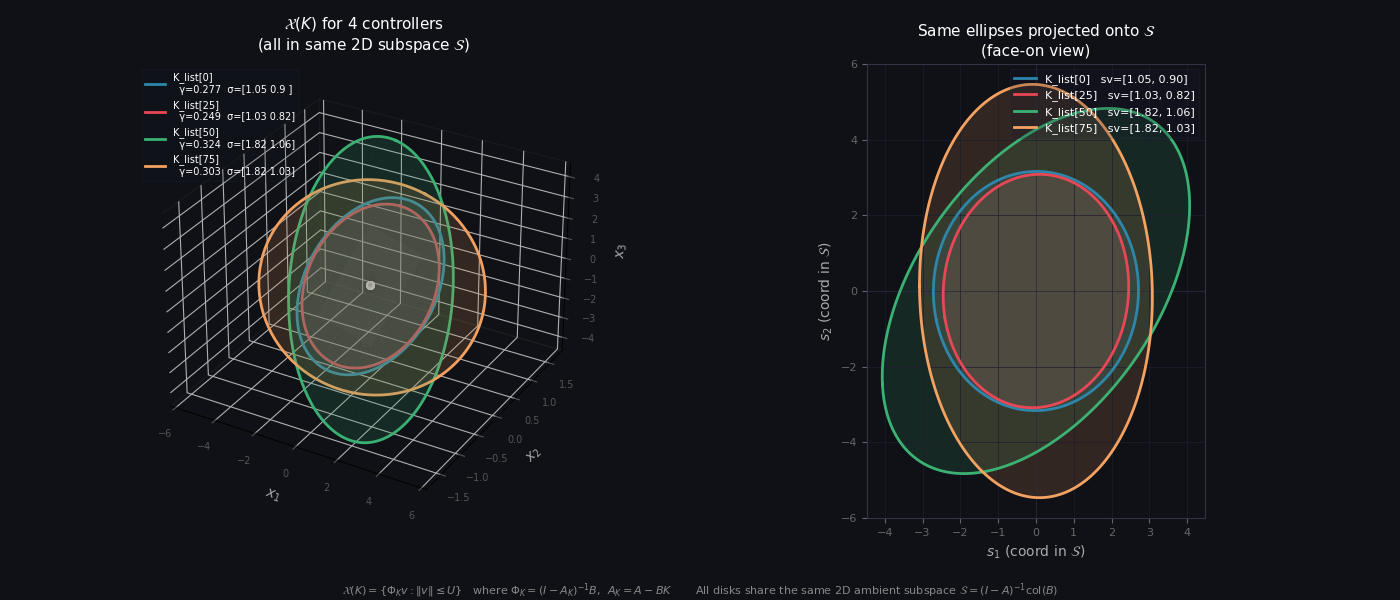

In [6]:
### Unchanged from the Affine Benchmark notebook for visualising the ellipsoids.
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import solve_discrete_lyapunov, sqrtm
%matplotlib widget

# ── Choose 4 controllers with notably different ellipsoid shapes ──────────────
indices  = [0, 25, 50, 75]
colors   = ['#2E86AB', '#E84855', '#3BB273', '#F4A261']
labels   = [f'K_list[{i}]' for i in indices]
ctrls    = [K_list[i] for i in indices]

# ── Parametrise ellipsoid boundaries ─────────────────────────────────────────
# v(theta) = U * [cos, sin] traces the boundary of the unit ball in R^2.
# z(theta) = Phi_K @ v(theta)  traces the boundary ellipse of X(K) in R^3.
# Fill the disk:  v(r, theta) = r * U * [cos, sin], r in [0,1].
N_theta  = 200
N_r      = 40
theta    = np.linspace(0, 2*np.pi, N_theta)
r_vals   = np.linspace(0, 1, N_r)

# ── Shared subspace for reference plane ───────────────────────────────────────
I_n   = np.eye(DIM_X)
Phi0  = np.linalg.solve(I_n - A, B)       # basis for shared 2D subspace S
Q_S, _ = np.linalg.qr(Phi0)              # orthonormal basis for S
e1, e2 = Q_S[:, 0], Q_S[:, 1]            # unit vectors spanning S

# Subspace plane grid for background reference
grid_s = np.linspace(-1.5, 1.5, 30)      # coords in subspace basis
ss, tt = np.meshgrid(grid_s, grid_s)
plane_x = ss * e1[0] + tt * e2[0]
plane_y = ss * e1[1] + tt * e2[1]
plane_z = ss * e1[2] + tt * e2[2]

# ── Build figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor('#0F1117')

# Left: all 4 ellipsoids overlaid in one 3D plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#0F1117')

# Draw the shared subspace as a faint reference plane
ax1.plot_surface(plane_x, plane_y, plane_z,
                 color='white', alpha=0.04, linewidth=0, zorder=0)

# Draw each ellipsoid disk
for ctrl, col, lbl in zip(ctrls, colors, labels):
    Phi = ctrl['Phi_K']

    # Filled disk: all points Phi @ v for ||v|| <= U
    xs, ys, zs = [], [], []
    for r in r_vals:
        v_ring = r * U * np.stack([np.cos(theta), np.sin(theta)], axis=0)  # (2, N)
        pts    = Phi @ v_ring                                                # (3, N)
        xs.append(pts[0]); ys.append(pts[1]); zs.append(pts[2])
    xs = np.array(xs); ys = np.array(ys); zs = np.array(zs)

    # Surface (faint fill)
    ax1.plot_surface(xs, ys, zs, color=col, alpha=0.18, linewidth=0)

    # Boundary ellipse (solid)
    v_bnd = U * np.stack([np.cos(theta), np.sin(theta)], axis=0)
    bnd   = Phi @ v_bnd
    ax1.plot(bnd[0], bnd[1], bnd[2], color=col, linewidth=2.0,
             label=f'{lbl}\n  γ={ctrl["gamma_K"]:.3f}  σ={np.linalg.svd(Phi, compute_uv=False).round(2)}')

    # Mark centre (origin)
    ax1.scatter([0], [0], [0], color='white', s=30, zorder=10)

ax1.set_xlabel('$x_1$', color='#AAAAAA', labelpad=4)
ax1.set_ylabel('$x_2$', color='#AAAAAA', labelpad=4)
ax1.set_zlabel('$x_3$', color='#AAAAAA', labelpad=4)
ax1.tick_params(colors='#555555', labelsize=7)
for pane in [ax1.xaxis.pane, ax1.yaxis.pane, ax1.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('#222222')
ax1.grid(True, color='#1E1E2E', linewidth=0.4)
ax1.set_title('$\mathcal{X}(K)$ for 4 controllers\n(all in same 2D subspace $\mathcal{S}$)',
              color='white', fontsize=11, pad=10)
leg = ax1.legend(loc='upper left', fontsize=7, framealpha=0.15,
                 labelcolor='white', facecolor='#1A1A2E', edgecolor='#333344')

# Right: 2D projection onto the shared subspace coordinates (s, t)
# This shows the ellipses "face-on" in S
ax2 = fig.add_subplot(122)
ax2.set_facecolor('#0F1117')
ax2.set_aspect('equal')

for ctrl, col, lbl in zip(ctrls, colors, labels):
    Phi = ctrl['Phi_K']
    sv  = np.linalg.svd(Phi, compute_uv=False)

    # Boundary in subspace coordinates: project Phi@v onto (e1, e2)
    v_bnd = U * np.stack([np.cos(theta), np.sin(theta)], axis=0)
    bnd   = Phi @ v_bnd                     # (3, N) in R^3
    s_coords = Q_S.T @ bnd                  # (2, N) in subspace coords

    # Filled ellipse
    ax2.fill(s_coords[0], s_coords[1], color=col, alpha=0.15)
    # Boundary
    ax2.plot(s_coords[0], s_coords[1], color=col, linewidth=2,
             label=f'{lbl}   sv=[{sv[0]:.2f}, {sv[1]:.2f}]')

ax2.axhline(0, color='#333344', linewidth=0.8, zorder=0)
ax2.axvline(0, color='#333344', linewidth=0.8, zorder=0)
ax2.set_xlabel('$s_1$ (coord in $\mathcal{S}$)', color='#AAAAAA')
ax2.set_ylabel('$s_2$ (coord in $\mathcal{S}$)', color='#AAAAAA')
ax2.tick_params(colors='#666666', labelsize=8)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333344')
ax2.set_title('Same ellipses projected onto $\mathcal{S}$\n(face-on view)',
              color='white', fontsize=11)
ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white',
           facecolor='#1A1A2E', edgecolor='#333344', loc='upper right')
ax2.grid(True, color='#1E1E2E', linewidth=0.5)

# Annotation
fig.text(0.5, 0.01,
         r'$\mathcal{X}(K) = \{\Phi_K v : \|v\| \leq U\}$   '
         r'where $\Phi_K = (I - A_K)^{-1}B$,  $A_K = A - BK$   '
         r'$\quad$ All disks share the same 2D ambient subspace $\mathcal{S} = (I-A)^{-1}\mathrm{col}(B)$',
         ha='center', color='#888888', fontsize=8)

plt.tight_layout(rect=[0, 0.04, 1, 1])

## Uncomment below if you want to generate the slider. It is commented out by default because it can be a bit slow to render .
# ── Sliders for azimuth and elevation ────────────────────────────────────────
# from matplotlib.widgets import Slider
 
# ax_az  = fig.add_axes([0.12, 0.06, 0.35, 0.025])
# ax_el  = fig.add_axes([0.12, 0.02, 0.35, 0.025])
 
# for ax_s in [ax_az, ax_el]:
#     ax_s.set_facecolor('#1A1A2E')
#     for spine in ax_s.spines.values():
#         spine.set_edgecolor('#333344')
 
# sl_az = Slider(ax_az, 'Azimuth',  -180, 180, valinit=-60, color='#2E86AB')
# sl_el = Slider(ax_el, 'Elevation',  -90,  90, valinit=20,  color='#3BB273')
 
# for sl in [sl_az, sl_el]:
#     sl.label.set_color('white')
#     sl.valtext.set_color('white')
 
# def update(val):
#     ax1.view_init(elev=sl_el.val, azim=sl_az.val)
#     fig.canvas.draw_idle()
 
# sl_az.on_changed(update)
# sl_el.on_changed(update)
 

plt.show()

#### Running the BatchFTPL algorithm and the batchwise state update. 

We create a function that decomposes th system into two components: nominal and disturbance driven. And then updates one using the bathFTPL generated (K_n,v_N) in the nth batch i.e. 

$ \bar{x}_{t+1} = (A-B K_n) \bar{x}_t + B v_n $

and the other simple propagating over the disturbance 

$ x^d_{t+1} = (A - BK_0) x^d  + w_t

It then spits out the state at the end of the batch, and the sequence of costs incurred in the batch. The sipt out state can then be used for the next batch in the main batch-FTPL loop.  

In [7]:
# ── Cell 5: Batch runner and BatchFTPL main loop ─────────────────────────────

# New version of run_batch with ability to perform inner-loop FTPL on v.
def run_batch(x_bar, x_d, K_n, v_seq, A, B, K0, H, Q_seq, c_seq, w_seq, t_start):
    """
    Simulate H steps of the closed-loop system for one batch under a fixed gain
    K_n and a per-step offset sequence v_seq.

    State decomposition
    -------------------
    The full state x_t = x_bar_t + x_d_t is split into two parts:

      x_bar: nominal state, driven by the affine controller (K_n, v_n)
        x_bar_{t+1} = (A - B K_n) x_bar_t + B v_n

      x_d: disturbance state, driven by the fixed rejection gain K_0
        x_d_{t+1}   = (A - B K_0) x_d_t   + w_t

    The applied input at each step is:
        u_t = -K_n x_bar_t - K_0 x_d_t + v_n


        ----------
    x_bar    : (DIM_X,)  nominal state at start of batch
    x_d      : (DIM_X,)  disturbance state at start of batch
    K_n      : (DIM_U x DIM_X)  feedback gain for this batch (from oracle)
    v_seq    : (H, DIM_U) or (DIM_U,)
                Offset applied at each step. A 1-D vector is broadcast to all H steps
                (recovers the original fixed-offset BatchFTPL behaviour). A full (H, DIM_U)
                sequence is used when v is refined within the batch (inner-loop FTPL).
    K0       : (DIM_U x DIM_X)  fixed disturbance-rejection gain
    H        : int, number of steps in this batch
    Q_seq    : (H, DIM_X, DIM_X)  cost matrices for steps t_start ... t_start+H-1
    c_seq    : (H, DIM_X)         cost centres for the same steps
    w_seq    : (H, DIM_X)         disturbances for the same steps
    t_start  : int, global time index of first step in this batch (for indexing)


    Returns
    -------
    x_bar_new, x_d_new : (DIM_X,) states at end of batch
    costs              : (H,)      stage costs f_t(x_t)
    states             : (H, DIM_X) full states x_t = x_bar_t + x_d_t
    """

    # Backward compatibility: if v_seq is 1D, broadcast same input to all H steps. 
    v_seq = np.atleast_2d(v_seq)
    if v_seq.shape[0] == 1:
        v_seq = np.repeat(v_seq, H, axis=0)   

    A_Kn = A - B @ K_n
    A_K0 = A - B @ K0

    costs  = np.zeros(H)
    states = np.zeros((H, x_bar.shape[0]))

    for h in range(H):
        v_t = v_seq[h]

        x_t        = x_bar + x_d
        states[h]  = x_t
        diff       = x_t - c_seq[h]
        costs[h]   = diff @ Q_seq[h] @ diff

        x_bar = A_Kn @ x_bar + B @ v_t
        x_d   = A_K0 @ x_d   + w_seq[h]

    return x_bar, x_d, costs, states

# ── Run BatchFTPL with inner-loop FTPL on v ─────────────────────────────────
# This is the main loop for the full algorithm with inner-loop FTPL on v.
# oracle_c_seq is fed the nomiunal costs (c_t - x_d_t) that the oracle accumulator sees. 

def run_batch_ftpl(A, B, K0, K_list, x0, T, H, U, Q_seq, c_seq, w_seq,
                   sigma, oracle_c_seq=None, update_v_within_batch=False,
                   sigma_inner=None):
    """
    BatchFTPL with an optional inner-loop v-only FTPL update.

    Outer loop (every H steps): full oracle scan over K_list picks (z_n, K_n, v_n).
    Inner loop (every step, when update_v_within_batch=True): with K_n frozen,
    re-solve the FTPL subproblem for v alone against the cumulative cost seen so far.

    Causality / correctness note
    ----------------------------
    The accumulator is a function of the exogenous cost data (Q_t, oracle_c_t) only
    -- it never depends on the realised trajectory (x_d evolves under K0 and w
    alone, independent of any v). So the within-batch v-sequence is computed by
    rolling the accumulator forward one step at a time: v at step (t_start+h) uses
    costs up to t_start+h-1, then that step's cost is folded in. This is exactly
    equivalent to computing v_t on-the-fly during simulation, and at h=0 it
    reproduces the outer oracle's v_n.

    Parameters
    ----------
    oracle_c_seq : (T, DIM_X) or None
        Nominal cost centres bar_c_t = c_t - x_d_t for the oracle accumulator.
        None -> falls back to c_seq (correct only when disturbances are zero).
    update_v_within_batch : bool
        False -> original fixed-(K,v)-per-batch BatchFTPL.
        True  -> refine v every step inside each batch (K_n fixed).
    sigma_inner : (DIM_X,) or None
        Perturbation for the inner loop. None -> reuse the outer sigma (Phase 1
        default). Exposed now for the later sigma-scaling study.
    """
    if oracle_c_seq is None:
        oracle_c_seq = c_seq
    if sigma_inner is None:
        sigma_inner = sigma

    DIM_X       = x0.shape[0]
    N_batches   = int(np.ceil(T / H))
    accumulator = QuadraticAccumulator(DIM_X)

    x_bar = x0.copy()
    x_d   = np.zeros(DIM_X)

    cost_seq_out  = np.zeros(T)
    state_seq_out = np.zeros((T, DIM_X))
    z_seq_out     = np.zeros((N_batches, DIM_X))

    for n in range(N_batches):
        t_start = n * H
        t_end   = min(t_start + H, T)
        h_this  = t_end - t_start

        # ── 1. Oracle: choose (z_n, K_n, v_n) ────────────────────────────────
        # This n==0 case is a bit hacky but it is just to get the first batch running without having to worry 
        # the oracle picking a bad controller. In practice this "bad" initial; controller would lead to a fixed offset in the regret bound
        # but because a lot of these computations are difficult to run on my laptop, I want to show the results meaningfully even with shorter horizons.
        # First batch: no cost history, oracle would go to boundary.
        # Return z*=0 as a neutral starting point.
        if n == 0:
            # First batch: no cost history; neutral start (see design note).
            z_n, ctrl_n, v_n = np.zeros(DIM_X), K_list[0], np.zeros(DIM_U)
        else:
            z_n, ctrl_n, v_n = ftpl_oracle(accumulator, K_list, sigma, U)
        z_seq_out[n] = z_n

        # ── 2. Build the offset sequence for this batch ──────────────────────
        # Inner v-FTPL is active only for n>0 (mirrors the first-batch hack and
        # keeps the accumulator non-empty so the subproblem is well-posed).
        Phi_Kn = ctrl_n['Phi_K']
        inner  = update_v_within_batch and n > 0
        v_seq  = np.zeros((h_this, DIM_U))
        for h in range(h_this):
            if inner:
                _, v_seq[h], _ = accumulator.subproblem(Phi_Kn, sigma_inner, U)
            else:
                v_seq[h] = v_n
            # Advance the accumulator with this step's NOMINAL cost so the next
            # inner solve (and the next batch's outer oracle) sees it.
            accumulator.update(Q_seq[t_start + h], oracle_c_seq[t_start + h])

        # ── 3. Simulate the batch under (K_n, v_seq) ─────────────────────────
        x_bar, x_d, costs, states = run_batch(
            x_bar, x_d,
            ctrl_n['K'], v_seq,
            A, B, K0, h_this,
            Q_seq[t_start:t_end],
            c_seq[t_start:t_end],
            w_seq[t_start:t_end],
            t_start,
        )
    
        cost_seq_out[t_start:t_end]  = costs
        state_seq_out[t_start:t_end] = states

    total_cost = float(np.sum(cost_seq_out))
    return total_cost, cost_seq_out, state_seq_out, z_seq_out

### Testing the batchFTPL and the Batch State updater.
...

In [8]:
# ── Cell 5 validation ─────────────────────────────────────────────────────────
# Assumes cells 1-5 have already run (A, B, K0, K_list, H, U, W,
# QuadraticAccumulator, ftpl_oracle, run_batch, run_batch_ftpl all in scope).

rng_val = np.random.default_rng(0)
T_val   = H_FTPL * 5    # 5 complete batches

# ── Test 1: zero disturbances, cost centred at origin ─────────────────────────
#
# Setup: Q_t = I, c_t = 0, w_t = 0, x0 = 0, sigma = 0.
# The global minimiser of every cost is z* = 0. With x0 = 0 and no
# disturbances, the state should stay at 0 and costs should be negligible.
# The oracle targets z_n should converge toward 0 across batches.

print("=" * 60)
print("Test 1: zero disturbances, cost centred at origin")
print("=" * 60)

Q_seq1 = np.stack([np.eye(DIM_X)] * T_val)
c_seq1 = np.zeros((T_val, DIM_X))
w_seq1 = np.zeros((T_val, DIM_X))
sigma1 = np.zeros(DIM_X)

## Start at non-zero x0 to show convergence of states and oracle targets toward 0. With x0=0 they would just stay at 0 and it would be less interesting.
x0 = np.array([0.5, -0.3, 0.2])

total1, cost_seq1, state_seq1, z_seq1 = run_batch_ftpl(
    A, B, K0, K_list, x0, T_val, H_FTPL, U,
    Q_seq1, c_seq1, w_seq1, sigma1
)

print(f"\n  Total cost         : {total1:.6f}       ")
print(f"  Max |state|        : {np.abs(state_seq1).max():.6f}   ")
print(f"  Min |state|        : {np.abs(state_seq1).min():.6f}   expect ≈ 0")
print(f"\n  Oracle targets z_n per batch (expect ≈ 0 in all):")
for n, z in enumerate(z_seq1):
    print(f"    batch {n}: {z.round(6)}")


# ── Test 2: single-batch manual consistency check ─────────────────────────────
#
# Run run_batch_ftpl for exactly one batch, then replicate the same
# computation manually (oracle on empty accumulator + run_batch directly).
# The states and costs must match to machine precision.

print()
print("=" * 60)
print("Test 2: single-batch consistency with manual replication")
print("=" * 60)

rng2   = np.random.default_rng(7)
Q_seq2 = np.stack([M.T @ M + 0.1 * np.eye(DIM_X)
                   for M in rng2.standard_normal((H_FTPL, DIM_X, DIM_X))])
c_seq2 = rng2.standard_normal((H_FTPL, DIM_X))
w_seq2 = np.zeros((H_FTPL, DIM_X))
sigma2 = np.zeros(DIM_X)
x0_2   = np.zeros(DIM_X)

# Algorithm path
total2, cost_seq2, state_seq2, z_seq2 = run_batch_ftpl(
    A, B, K0, K_list, x0_2, H_FTPL, H_FTPL, U,
    Q_seq2, c_seq2, w_seq2, sigma2
)

# Manual path: oracle on empty accumulator then run_batch directly
acc_manual = QuadraticAccumulator(DIM_X)
z_manual, ctrl_manual, v_manual = ftpl_oracle(acc_manual, K_list, sigma2, U)
_, _, costs_manual, states_manual = run_batch(
    x0_2, np.zeros(DIM_X),
    ctrl_manual['K'], v_manual,
    A, B, K0, H_FTPL,
    Q_seq2, c_seq2, w_seq2,
    t_start=0
)

print(f"\n  Oracle target (algorithm) : {z_seq2[0].round(6)}")
print(f"  Oracle target (manual)    : {z_manual.round(6)}")
print(f"  ‖z diff‖                  : {np.linalg.norm(z_seq2[0] - z_manual):.2e}  (expect ≈ 0)")
print(f"\n  Per-step cost comparison:")
print(f"  {'step':>4}  {'algorithm':>12}  {'manual':>12}  {'|diff|':>10}")
for h in range(H_FTPL):
    print(f"  {h:>4}  {cost_seq2[h]:>12.6f}  {costs_manual[h]:>12.6f}  "
          f"{abs(cost_seq2[h]-costs_manual[h]):>10.2e}")
print(f"\n  Max |cost diff|  : {np.abs(cost_seq2 - costs_manual).max():.2e}  (expect ≈ 0)")
print(f"  Max |state diff| : {np.abs(state_seq2 - states_manual).max():.2e}  (expect ≈ 0)")


# ── Test 3: disturbances only, states remain bounded ──────────────────────────
#
# Setup: zero costs, nonzero disturbances w_t ~ Uniform([-W, W]).
# K0 is stable so x_d contracts geometrically. With x0 = 0 and zero costs
# the oracle targets z = 0 throughout, so x_bar stays at 0.
# The full state x_t = x_bar_t + x_d_t should remain small and bounded.
# Rough bound: ||x_d|| <= W / gamma_K0  (geometric series of disturbances).

print()
print("=" * 60)
print("Test 3: disturbances only, states must stay bounded")
print("=" * 60)

w_seq3 = rng_val.uniform(-W, W, size=(T_val, DIM_X))
Q_seq3 = np.zeros((T_val, DIM_X, DIM_X))    # zero cost — oracle target stays 0
c_seq3 = np.zeros((T_val, DIM_X))
sigma3 = np.zeros(DIM_X)

_, _, state_seq3, z_seq3 = run_batch_ftpl(
    A, B, K0, K_list, np.zeros(DIM_X), T_val, H_FTPL, U,
    Q_seq3, c_seq3, w_seq3, sigma3
)

rough_bound = W / gamma_K0
print(f"\n  W = {W},  gamma_K0 = {gamma_K0:.3f}")
print(f"  Rough bound W/gamma_K0 = {rough_bound:.4f}")
print(f"  Max |state| observed   = {np.abs(state_seq3).max():.4f}  (expect << {rough_bound:.2f})")
print(f"  Oracle targets z_n (expect all ≈ 0 since cost is zero):")
for n, z in enumerate(z_seq3):
    print(f"    batch {n}: {z.round(6)}")

### Reset x0 to zero for remainder of notebook.
x0 = np.zeros(DIM_X)

Test 1: zero disturbances, cost centred at origin

  Total cost         : 0.465722       
  Max |state|        : 0.500000   
  Min |state|        : 0.000000   expect ≈ 0

  Oracle targets z_n per batch (expect ≈ 0 in all):
    batch 0: [0. 0. 0.]
    batch 1: [0. 0. 0.]
    batch 2: [0. 0. 0.]
    batch 3: [0. 0. 0.]
    batch 4: [0. 0. 0.]

Test 2: single-batch consistency with manual replication

  Oracle target (algorithm) : [0. 0. 0.]
  Oracle target (manual)    : [0. 0. 0.]
  ‖z diff‖                  : 0.00e+00  (expect ≈ 0)

  Per-step cost comparison:
  step     algorithm        manual      |diff|
     0      8.621116      8.621116    0.00e+00
     1     11.621827     11.621827    0.00e+00
     2      1.964157      1.964157    0.00e+00
     3      0.606096      0.606096    0.00e+00
     4      1.626621      1.626621    0.00e+00
     5      4.723687      4.723687    0.00e+00
     6      1.676810      1.676810    0.00e+00
     7      0.344883      0.344883    0.00e+00
     8     

### Generating various functions to help out with implementing the various benchmarks.

We consider three benchmarks 
1) **Best steady state under fixed input** - This is the theoretical benchmark proposed in "Revisiting Regret Benchmarks in Onlinhe Non-stochastic Control." CDC 2025

2) **Best steady state under affine control** - This is the new benchmark proposed in "Steady-state Approach to Online Non-stochastic Control" CDC 2026

2) **Best disturbance feedforward** (No longer implemented) - This is the true benchmark that the Agarwal work compares to. They show that the cost incurred by on specific instance of such a controller is close that of the best linear controller in hindsight. And then they argue that there is no loss of generality in considering this class. The advantage with this benchmark is that the cost functions are convex w.r.t to such feedforward controller matrices and so computing this benchmark ie easier. While Agarwal present theoretical results w.r.t to fixed linear feedback controller, this disturbance controller benchmark is stronger (and really what they can achieve good performance against) so we compare against that. 

_______________________________________________________________________________________

1) compute-xd-sequence : Straightforward propagates the closed loop dynamics with base controller and no feed-forward - $x_{t+1} = (A-BK_0) x_t + w_t$ - Validated.

2) vectorize_M and unvectorize_M (No longer implemented): functions that help out with re-writing the DAC matrices $\{M\}$ as a single vector to help out with writing it out as a convex program. Same as what was used for previous implementation of DAC for CDC 2025. 

3) compute_phi_list (No longer implemented): This obtains the expression for $x_t$ as $x_T = phi[t-1] m$ where $m$ is the vectorized version of the DAC matrices $\{M\}$. This function is used to compute the benchmark only as it is then as simple as solving for \sum_t  m \phi_t^T Q_t \phi_t m which is in standard quadratic form for m. Validated.

4) compute_bih_z_cumcost: This simple sums up the cost functions up until a certain time (using the quadratic structure to save only the $\sum Q_t$ and $\sum Q_t c_t$) and calls the oracle used by the ftpl algo to solve the $N_K$ convex problems for eack controller in $N_K$.

5) compute_bih_fixed_cumcost: Same as above but solves only one convex problem. Validated.


6) compute_bih_DAC_cumcost (No longer implemented): This relies heavily on the vec torized form of M and the phi list computed. It leverages this function to cast the DAC problem as a Standard Quadratic problem with a vector variable $m = vec(\{M_i\})$. This last function is identical to what was used in CDC 2025 so was validated previously. 

In [9]:
# ── Cell 6: Benchmark functions ───────────────────────────────────────────────
#
# Three benchmarks, all computed in NOMINAL coordinates:
#
#   g_t(z) = (z - bar_c_t)^T Q_t (z - bar_c_t)
#   where bar_c_t = c_t - x_d_t  (disturbance state subtracted from cost centre)
#
# BIH-Z     : min_{z ∈ Z} Σ_t g_t(z)   — steady-state, best affine controller
# BIH-fixed : min_{z ∈ X} Σ_t g_t(z)   — steady-state, best constant input
# DAC       : min_{‖M^[i]‖≤bound_i} Σ_{t≥2} g_t(Phi_list[t-2] @ m)
#              — trajectory-based; DAC can only affect state from t=2 onward
#
# The algorithm cumulative cost is Σ_t f_t(x_t) = Σ_t g_t(x_bar_t), so
# regret_t = cumsum(cost_seq)[t] - benchmark_cumcost[t].

# ── Part 1: Disturbance state precomputation ──────────────────────────────────

def compute_xd_sequence(w_seq, A_K0, T):
    """
    Compute the disturbance state x_d_t for t = 0, ..., T-1 under:
        x_d_{t+1} = A_K0 @ x_d_t + w_seq[t],    x_d_0 = 0.

    This is the trajectory that would be produced by the fixed gain K_0 acting
    on the disturbance channel in isolation, and is used to translate cost
    centres:  bar_c_t = c_t - x_d_t.

    Parameters
    ----------
    w_seq : (T, DIM_X)   disturbance sequence, w_seq[t] = w_t
    A_K0  : (DIM_X, DIM_X)  closed-loop matrix  A - B K_0
    T     : int

    Returns
    -------
    x_d_seq : (T, DIM_X)  where x_d_seq[t] = x_d_t
    """
    DIM_X   = w_seq.shape[1]
    x_d_seq = np.zeros((T, DIM_X))
    x_d     = np.zeros(DIM_X)
    for t in range(T):
        x_d_seq[t] = x_d
        x_d = A_K0 @ x_d + w_seq[t]
    return x_d_seq

# ── Part 3: Benchmark cumulative cost functions ───────────────────────────────

def compute_bih_z_cumcost(Q_seq, bar_c_seq, K_list, U, H):
    """
    BIH-Z benchmark: best in hindsight over Z (union of steady-state sets).

    At each batch boundary t = H-1, 2H-1, ..., solves:
        min_{z ∈ Z}  Σ_{s=0}^{t} g_s(z)
    using ftpl_oracle with σ=0 on the accumulated (Q_acc, q_acc).

    Evaluated at batch boundaries only (every H steps) because each oracle
    call requires N_K CVXPY solves.  Returns sparse (t_vals, cumcosts) arrays
    suitable for regret plots; align with algorithm cumsum at those indices.

    Parameters
    ----------
    Q_seq     : (T, DIM_X, DIM_X)  cost matrices  (numpy array)
    bar_c_seq : (T, DIM_X)         translated cost centres  c_t - x_d_t
    K_list    : list of controller dicts from sample_stabilizing_controllers
    U         : float, norm bound on offset v
    H         : int, batch size (checkpoints every H steps)

    Returns
    -------
    t_vals    : (N_checkpoints,) int array of time indices where evaluated
    cumcosts  : (N_checkpoints,) float array of BIH-Z cumulative costs
    """
    T         = len(Q_seq)
    DIM_X     = Q_seq[0].shape[0]
    sigma_0   = np.zeros(DIM_X)
    acc       = QuadraticAccumulator(DIM_X)
    const_acc = 0.0

    t_vals   = []
    cumcosts = []

    for t in range(T):
        acc.update(Q_seq[t], bar_c_seq[t])
        const_acc += bar_c_seq[t] @ Q_seq[t] @ bar_c_seq[t]

        # Evaluate at batch boundaries and at the final step
        if (t + 1) % H == 0 or t == T - 1:
            z_star, _, _ = ftpl_oracle(acc, K_list, sigma_0, U)
            # Full cost: z^T Q_acc z - 2 q_acc^T z + Σ bar_c^T Q bar_c
            min_cost = (z_star @ acc.Q_acc @ z_star
                        - 2.0 * acc.q_acc @ z_star
                        + const_acc)
            t_vals.append(t)
            cumcosts.append(float(min_cost))

    return np.array(t_vals), np.array(cumcosts)


def compute_bih_fixed_cumcost(Q_seq, bar_c_seq, A, B, U):
    """
    BIH-fixed benchmark: best in hindsight over X = {(I-A)^{-1}Bu : ‖u‖ ≤ U}.

    At each time step t solves:
        min_{z ∈ X}  Σ_{s=0}^{t} g_s(z)

    X(K=0) = {Phi_0 u : ‖u‖ ≤ U}  where Phi_0 = (I-A)^{-1} B.
    Reuses QuadraticAccumulator.subproblem with Phi_K = X_mat at σ=0.
    One CVXPY solve per time step.

    Parameters
    ----------
    Q_seq     : (T, DIM_X, DIM_X)
    bar_c_seq : (T, DIM_X)
    A, B      : system matrices
    U         : float, norm bound on u

    Returns
    -------
    cumcosts : (T,) float array; cumcosts[t] = BIH-fixed cost up to time t
    """
    T         = len(Q_seq)
    DIM_X     = Q_seq[0].shape[0]
    I_n       = np.eye(DIM_X)
    X_mat     = np.linalg.solve(I_n - A, B)    # (I-A)^{-1} B, steady-state map
    sigma_0   = np.zeros(DIM_X)
    acc       = QuadraticAccumulator(DIM_X)
    const_acc = 0.0
    cumcosts  = np.zeros(T)

    for t in range(T):
        acc.update(Q_seq[t], bar_c_seq[t])
        const_acc += bar_c_seq[t] @ Q_seq[t] @ bar_c_seq[t]

        z_star, _, _ = acc.subproblem(X_mat, sigma_0, U)
        cumcosts[t]  = (z_star @ acc.Q_acc @ z_star
                        - 2.0 * acc.q_acc @ z_star
                        + const_acc)

    return cumcosts


##### Need to randomize to see that 10 Ks are actually worse than 100 Ks.

In [22]:
# # ── Cell 6 validation ─────────────────────────────────────────────────────────
# # Assumes cells 1-6 already run (A, B, K0, A_K0, K_list, H, U, W, DIM_X, DIM_U,
# # gamma_K0, kappa_K0, QuadraticAccumulator, ftpl_oracle, all in scope).

# rng_v = np.random.default_rng(99)

# # ─────────────────────────────────────────────────────────────────────────────
# # Test 3: compute_xd_sequence — correctness and stability
# # ─────────────────────────────────────────────────────────────────────────────
# # With w=0: x_d_t = 0 for all t (A_K0 applied to 0 stays 0).
# # With nonzero w: x_d_t should remain bounded (A_K0 is stable).

# print()
# print("=" * 60)
# print("Test 3: compute_xd_sequence")
# print("=" * 60)

# A_K0_val = A - B @ K0

# # Zero disturbances: x_d must stay zero
# w_zero   = np.zeros((T_test, DIM_X))
# x_d_zero = compute_xd_sequence(w_zero, A_K0_val, T_test)
# print(f"\n  w=0:  max |x_d_t| = {np.abs(x_d_zero).max():.2e}  (expect ≈ 0)")

# # Nonzero disturbances: check recursion x_d[t+1] = A_K0 @ x_d[t] + w[t]
# w_nz  = rng_v.standard_normal((T_test, DIM_X)) * W
# x_d_t = compute_xd_sequence(w_nz, A_K0_val, T_test)
# print(f"  w≠0:  max |x_d_t| = {np.abs(x_d_t).max():.4f}")

# # Verify the recursion manually for t=0,...,4
# print(f"\n  Checking recursion x_d[t+1] = A_K0 @ x_d[t] + w[t] for t=0,...,4:")
# for t_chk in range(5):
#     lhs = x_d_t[t_chk + 1] if t_chk + 1 < T_test else None
#     rhs = A_K0_val @ x_d_t[t_chk] + w_nz[t_chk]
#     err = np.linalg.norm(lhs - rhs) if lhs is not None else float('nan')
#     print(f"  t={t_chk}: ‖x_d[{t_chk+1}] - (A_K0@x_d[{t_chk}] + w[{t_chk}])‖ = {err:.2e}")


# # ─────────────────────────────────────────────────────────────────────────────
# # Test 4: BIH-fixed — cost at known minimiser
# # ─────────────────────────────────────────────────────────────────────────────
# # If all bar_c_t = c* and Q_t = I, the minimiser of Σ g_t(z) over X is the
# # projection of c* onto X. Verify the computed cumcost equals the expected value.
# # Also check that cumcosts are non-decreasing (best-in-hindsight can only worsen
# # or stay the same as T grows, since adding costs can only hurt the fixed point).

# print()
# print("=" * 60)
# print("Test 4: compute_bih_fixed_cumcost — monotone and near-zero at target")
# print("=" * 60)

# X_mat_val = np.linalg.solve(np.eye(DIM_X) - A, B)

# # Case A: bar_c_t = 0 for all t. Best z in X minimising Σ ‖z‖² is z=0.
# # Cumcost at every t should be 0.
# T_bih       = 20
# Q_const     = np.stack([np.eye(DIM_X)] * T_bih)
# bar_c_zero  = np.zeros((T_bih, DIM_X))
# cc_zero     = compute_bih_fixed_cumcost(Q_const, bar_c_zero, A, B, U)
# print(f"\n  bar_c=0, Q=I: max cumcost = {cc_zero.max():.6f}  (expect ≈ 0)")

# # Case B: bar_c_t = c* reachable in X (c* = X_mat @ u* with ‖u*‖ < U).
# # The minimiser is z*=c*, cost at each t = Σ_s ‖c*-c*‖² = 0.
# u_star = np.array([0.5, 0.3])
# c_star = X_mat_val @ u_star
# bar_c_reach = np.tile(c_star, (T_bih, 1))
# cc_reach    = compute_bih_fixed_cumcost(Q_const, bar_c_reach, A, B, U)
# print(f"  bar_c=c*∈X, Q=I: max cumcost = {cc_reach.max():.6f}  (expect ≈ 0)")

# # Case C: random bar_c_t, check monotonicity
# bar_c_rand = rng_v.standard_normal((T_bih, DIM_X)) * 0.5
# cc_rand    = compute_bih_fixed_cumcost(Q_const, bar_c_rand, A, B, U)
# diffs_neg  = np.sum(np.diff(cc_rand) < -1e-6)   # should be 0
# print(f"  Random bar_c: cumcosts non-decreasing? {diffs_neg == 0}  ({diffs_neg} violations)")


# # ─────────────────────────────────────────────────────────────────────────────
# # Test 5: Larger K_list gives lower or equal BIH-Z cost
# # ─────────────────────────────────────────────────────────────────────────────
# # The theoretical ordering BIH-Z <= BIH-fixed requires X ⊆ Z_approx, which
# # only holds if K=0 is in K_list. Our sampler only generates nonzero LQR gains,
# # so K=0 is absent and the ordering can fail by a small amount proportional to
# # the approximation error of the discrete oracle.
# #
# # What IS guaranteed by construction: optimising over a larger set of controllers
# # gives a cost that is lower or equal. We test this by comparing:
# #   BIH-Z(K_list)         -- full 100 controllers
# #   BIH-Z(K_list[:10])    -- first 10 controllers only
# # The full set contains the small set, so full BIH-Z <= subset BIH-Z.

# print()
# print("=" * 60)
# print("Test 5: Larger K_list gives lower or equal BIH-Z cost")
# print("=" * 60)
# print("  (Theoretical BIH-Z <= BIH-fixed requires K=0 in K_list;")
# print("   our LQR sampler excludes K=0, so that ordering is not tested here.)")

# T_z      = H_FTPL * 4
# Q_r5     = np.stack([M.T @ M + 0.1*np.eye(DIM_X)
#                      for M in rng_v.standard_normal((T_z, DIM_X, DIM_X))])
# bar_c_r5 = rng_v.standard_normal((T_z, DIM_X)) * 0.5

# t_full, cc_full = compute_bih_z_cumcost(Q_r5, bar_c_r5, K_list,      U, H_FTPL)
# t_sub,  cc_sub  = compute_bih_z_cumcost(Q_r5, bar_c_r5, K_list[:10], U, H_FTPL)

# print(f"\n  {'t':>5}  {'BIH-Z (100 K)':>14}  {'BIH-Z (10 K)':>14}  {'full <= subset?':>15}")
# violations = 0
# for t_chk, bf, bs in zip(t_full, cc_full, cc_sub):
#     ok = bf <= bs + 1e-3
#     if not ok:
#         violations += 1
#     print(f"  {t_chk:>5}  {bf:>14.4f}  {bs:>14.4f}  {'OK' if ok else 'VIOLATION':>15}")

# print(f"\n  Violations: {violations} / {len(t_full)}  (expect 0)")


In [11]:
# A smart test case
# ── Find K_i with largest "stretching" relative to X ──────────────────────────
X_mat_val = np.linalg.solve(np.eye(DIM_X) - A, B)
X_pinv    = np.linalg.pinv(X_mat_val)

# For each K, compute X_mat^+ @ Phi_K and its max singular value.
# If > 1, Phi_K can reach points outside X within the same norm ball.
# Recall Phi_K = (I-A+BK)^{-1} B.
stretches = []
for ctrl in K_list:
    M_transform = X_pinv @ ctrl['Phi_K']           # 2x2
    sv_max      = np.linalg.svd(M_transform, compute_uv=False)[0]
    stretches.append(sv_max)

best_i  = int(np.argmax(stretches))
best_sv = stretches[best_i]
print(f"Best K_list[{best_i}]: max singular value of X_mat^+ @ Phi_K = {best_sv:.4f}")
# This must be > 1 for the test to work

# ── Construct z* inside X(K_i) but outside X ──────────────────────────────────
# v* along the right singular vector of X_mat^+ @ Phi_K, scaled to 0.95*U
M_transform = X_pinv @ K_list[best_i]['Phi_K']
_, _, Vt    = np.linalg.svd(M_transform)
v_star      = 0.95 * U * Vt[0]                     # along max stretch direction
z_star      = K_list[best_i]['Phi_K'] @ v_star

print(f"‖v*‖ = {np.linalg.norm(v_star):.4f}  (≤ U={U}, so z* ∈ X(K_i))")
print(f"‖X_mat^+ @ z*‖ = {np.linalg.norm(X_pinv @ z_star):.4f}  (expect > U={U})")

# ── Run benchmarks with bar_c_t = z* for all t ────────────────────────────────
# BIH-Z  : optimal z = z*, cost = 0
# BIH-fixed: must find best z ∈ X, which cannot reach z*, so cost > 0
T_gap      = H_FTPL * 4
Q_gap      = np.stack([100.0 * np.eye(DIM_X)] * T_gap)   # large Q to amplify gap
bar_c_gap  = np.tile(z_star, (T_gap, 1))

cc_fixed_gap          = compute_bih_fixed_cumcost(Q_gap, bar_c_gap, A, B, U)
t_gap, cc_z_gap       = compute_bih_z_cumcost(Q_gap, bar_c_gap, K_list, U, H_FTPL)

print(f"\nAt t={t_gap[-1]}:")
print(f"  BIH-Z     cumcost = {cc_z_gap[-1]:.4f}   (expect ≈ 0, z* reachable)")
print(f"  BIH-fixed cumcost = {cc_fixed_gap[-1]:.4f}  (expect > 0, z* not in X)")
print(f"  Gap = {cc_fixed_gap[t_gap[-1]] - cc_z_gap[-1]:.4f}  (expect > 0)")


Best K_list[8]: max singular value of X_mat^+ @ Phi_K = 1.0976
‖v*‖ = 2.8500  (≤ U=3.0, so z* ∈ X(K_i))
‖X_mat^+ @ z*‖ = 3.1281  (expect > U=3.0)

At t=43:
  BIH-Z     cumcost = -0.0000   (expect ≈ 0, z* reachable)
  BIH-fixed cumcost = 562.3538  (expect > 0, z* not in X)
  Gap = 562.3538  (expect > 0)


In [12]:
# ── Precompute X_mat, X_pinv, P_X ─────────────────────────────────────────────
I_n    = np.eye(DIM_X)
X_mat  = np.linalg.solve(I_n - A, B)       # (DIM_X x DIM_U)
X_pinv = np.linalg.pinv(X_mat)             # (DIM_U x DIM_X)
P_X    = X_mat @ X_pinv                    # (DIM_X x DIM_X) projector onto X

print(f"X_mat  shape: {X_mat.shape}")
print(f"X_pinv shape: {X_pinv.shape}")
print(f"P_X    shape: {P_X.shape}")
print(f"‖P_X² - P_X‖ = {np.linalg.norm(P_X @ P_X - P_X):.2e}  (expect ≈ 0, idempotent)")


def run_heb(A, B, x0, T, Q_seq, c_seq, w_seq,
            X_mat, X_pinv, P_X,
            gamma, kappa, kappa_B, D, W, U):
    """
    Heb algorithm (CDC 2025 paper): OGD on the steady-state set X.

    Parameters
    ----------
    A, B     : system matrices
    x0       : (DIM_X,) initial state
    T        : time horizon
    Q_seq    : (T, DIM_X, DIM_X)  cost matrices
    c_seq    : (T, DIM_X)         cost centres  (original, NOT bar_c)
    w_seq    : (T, DIM_X)         disturbance sequence
    X_mat    : (DIM_X, DIM_U)     steady-state map  (I-A)^{-1} B
    X_pinv   : (DIM_U, DIM_X)     Moore-Penrose pseudoinverse of X_mat
    P_X      : (DIM_X, DIM_X)     orthogonal projector onto col(X_mat)
    gamma, kappa, kappa_B : stability parameters for learning rate
    D        : float  state norm bound (used in learning rate)
    W        : float  disturbance bound (used in learning rate)
    U        : float  input norm bound

    Returns
    -------
    total_cost : float
    cost_seq   : (T,)       per-step costs  f_t(x_t)
    state_seq  : (T, DIM_X) full states  x_t
    """
    DIM_X = A.shape[0]

    # ── Learning rate ─────────────────────────────────────────────────────────
    # From Theorem 8 (CDC 2025).  Factor of 5*2 retained from the original
    # notebook for consistency with the published simulation results.
    max_norm_Q = max(np.linalg.norm(Q, ord='fro') for Q in Q_seq)
    max_norm_c = max(np.linalg.norm(c, ord=2)     for c in c_seq)
    Gc         = 2.0 * max_norm_Q * (max_norm_c + D)
    eta_H      = 5 * 2 * D * gamma / (Gc * T**0.5 * (1 + 4 * kappa**2)**0.5)

    x         = x0.copy()
    z         = np.zeros(DIM_X)      # target steady state, initialised at origin

    cost_seq_out  = np.zeros(T)
    state_seq_out = np.zeros((T, DIM_X))

    for t in range(T):

        # ── 1. Project z onto X, recover input ───────────────────────────────
        z   = P_X @ z                 # project onto col(X_mat)
        u_t = X_pinv @ z             # input that drives system to z

        # ── 2. Record state and cost ──────────────────────────────────────────
        state_seq_out[t] = x
        diff             = x - c_seq[t]
        cost_seq_out[t]  = diff @ Q_seq[t] @ diff

        # ── 3. OGD update using observed gradient ─────────────────────────────
        grad = 2.0 * Q_seq[t] @ diff   # ∇f_t(x_t)
        z    = z - eta_H * grad

        # ── 4. Advance state ──────────────────────────────────────────────────
        x = A @ x + B @ u_t + w_seq[t]

    total_cost = float(np.sum(cost_seq_out))
    return total_cost, cost_seq_out, state_seq_out

X_mat  shape: (3, 2)
X_pinv shape: (2, 3)
P_X    shape: (3, 3)
‖P_X² - P_X‖ = 1.14e-15  (expect ≈ 0, idempotent)


# Running the Trials 
Might need to either include the zero controller in $K_{list}$ or the fixed input controller with $A_K0$ else the baselne controller will probably turn out to be better.  

In [44]:
# ── Cell 8: Trial runner ──────────────────────────────────────────────────────
#
# Patch note: run_batch_ftpl now accepts oracle_c_seq separately from c_seq.
# Paste the patched version (cell5_fix.py) over the original run_batch_ftpl
# before running this cell.


def state_bound(x0, kappa, gamma, kappa_B, U, W):
    """
    Uniform upper bound D on ||x_t|| for all t:
        D = kappa * ||x0|| + (kappa / (1 - gamma)) * (kappa_B * U + W)
    Matches the formula from the original CDC notebook.
    """
    return kappa * np.linalg.norm(x0) + (kappa / (1 - gamma)) * (kappa_B * U + W)


def sample_trial_data(T, DIM_X, DIM_U, W, rng):
    """
    Sample one trial's cost and disturbance sequences.
    Matches the exact convention from the CDC / 2026 paper notebooks:
      Q_seq : uniform(-1,1) -> symmetric -> PD  (no additional scaling)
      c_seq : uniform(0, 1) per component
      w_seq : uniform(-1,1) per component, then normalised so max ||w_t|| = W exactly
    """
    Q_raw  = rng.uniform(-1, 1, (T, DIM_X, DIM_X))
    Q_seq  = np.array([Q.T @ Q for Q in Q_raw])               # (T, DIM_X, DIM_X) PD

    c_seq  = rng.uniform(0, 1, (T, DIM_X))                    # (T, DIM_X)

    w_raw  = rng.uniform(-1, 1, (T, DIM_X))
    w_norms = np.linalg.norm(w_raw, axis=1).max()
    w_seq  = W * w_raw / w_norms                               # (T, DIM_X)

    return Q_seq, c_seq, w_seq

# ── Timing patch for run_single_trial ────────────────────────────────────────
# Adds wall-clock timing for each algorithm and each benchmark component.
# All timings are returned in the result dict under 'timings'.
 
def run_single_trial(trial_idx, seed_base,
                     A, B, K0, A_K0, K_list,
                     x0, T, H_FTPL, U, W,
                     DIM_X, DIM_U,
                     gamma, kappa, kappa_B,
                     X_mat, X_pinv, P_X
                    ):
    rng = np.random.default_rng(seed_base + trial_idx)
 
    Q_seq, c_seq, w_seq = sample_trial_data(T, DIM_X, DIM_U, W, rng)
    x_d_seq   = compute_xd_sequence(w_seq, A_K0, T)
    bar_c_seq = c_seq - x_d_seq
    D         = state_bound(x0, kappa, gamma, kappa_B, U, W)
 
    # ── In Theorem 8 we pick RV with parameter \eta. But rng.exponential() defines scale as 1/eta.  ────────────────────────
    L     = 2.0 * max(np.linalg.norm(Q, 'fro') for Q in Q_seq) * \
                 (max(np.linalg.norm(c) for c in c_seq) + D)
    eta   = 1 / ( np.sqrt(np.ceil(T / H_FTPL))) #
    # In practice, we scale up \eta from tge theoretical optimal because in practice we do not need as small an eta!
    # I am manually scaling eta to make my noise magnitude be roughly \sqrt{T} * W which sort of captures the rough magnitude of cost faced in each step   
    # print(f"L = {L:4f}, N_batches = {np.ceil(T / H_FTPL)}, eta = {eta:.4e}")
    
    sigma = rng.exponential(scale=1/eta, size=DIM_X)
    
    print(f"Trial {trial_idx}: sigma = {sigma}")
    # print(f" w_seq[:5] = {w_seq[:5]}")  # print first 5 disturbances for sanity check
    # print(f" bar_c_seq[:5] = {bar_c_seq[:5]}")  # print first 5 adjusted costs for sanity check  

    # ── BatchFTPL ─────────────────────────────────────────────────────────────
    t0 = time.time()
    _, ftpl_costs, _, _ = run_batch_ftpl(
        A, B, K0, K_list, x0, T, H_FTPL, U,
        Q_seq, c_seq, w_seq, sigma,
        oracle_c_seq=bar_c_seq,
    )
    t_ftpl = time.time() - t0
 
    # ── BatchFTPL + inner-loop v update (Phase 1) ─────────────────────────────
    # Same instance, same sigma; only difference is per-step v refinement.
    t0 = time.time()
    _, ftpl_inner_costs, _, _ = run_batch_ftpl(
        A, B, K0, K_list, x0, T, H_FTPL, U,
        Q_seq, c_seq, w_seq, sigma,
        oracle_c_seq=bar_c_seq,
        update_v_within_batch=True,      # sigma_inner=None -> reuse outer sigma
    )
    t_ftpl_inner = time.time() - t0


    # ── Heb (CDC 2025) ────────────────────────────────────────────────────────
    t0 = time.time()
    _, heb_costs, _ = run_heb(
        A, B, x0, T, Q_seq, c_seq, w_seq,
        X_mat, X_pinv, P_X,
        gamma, kappa, kappa_B, D, W, U,
    )
    t_heb = time.time() - t0
 
    # ── BIH-Z benchmark ───────────────────────────────────────────────────────
    t0 = time.time()
    bih_z_t, bih_z_cc = compute_bih_z_cumcost(Q_seq, bar_c_seq, K_list, U, H_FTPL)
    t_bih_z = time.time() - t0
 
    # ── BIH-fixed benchmark ───────────────────────────────────────────────────
    t0 = time.time()
    bih_fix_cc = compute_bih_fixed_cumcost(Q_seq, bar_c_seq, A, B, U)
    t_bih_fix = time.time() - t0
 
    return dict(
        ftpl_costs  = ftpl_costs,
        ftpl_inner_costs = ftpl_inner_costs,
        heb_costs   = heb_costs,
        bih_z_t     = bih_z_t,
        bih_z_cc    = bih_z_cc,
        bih_fix_cc  = bih_fix_cc,
        timings     = dict(
            ftpl    = t_ftpl,     # BatchFTPL algorithm
            ftpl_inner = t_ftpl_inner,  # BatchFTPL with inner-loop updates
            heb     = t_heb,      # Heb algorithm
            bih_z   = t_bih_z,    # BIH-Z benchmark
            bih_fix = t_bih_fix,  # BIH-fixed benchmark
        ),
    )
 
 
def run_all_trials(N, seed_base,
                   A, B, K0, A_K0, K_list,
                   x0, T, H_FTPL, U, W,
                   DIM_X, DIM_U,
                   gamma, kappa, kappa_B,
                   X_mat, X_pinv, P_X,
                   n_jobs=4):
    t0 = time.time()
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(run_single_trial)(
            trial_idx, seed_base,
            A, B, K0, A_K0, K_list,
            x0, T, H_FTPL, U, W,
            DIM_X, DIM_U,
            gamma, kappa, kappa_B,
            X_mat, X_pinv, P_X
        )
        for trial_idx in range(N)
    )
    print(f"Completed {N} trials in {time.time()-t0:.1f}s  "
          f"({(time.time()-t0)/N:.1f}s per trial)")
    return results

# ── Simulation parameters ─────────────────────────────────────────────────────

T          = 5000  # time horizon  (2026 paper uses T=500)
N_trials   = 10   # number of trials  (2026 paper uses N=50)
BASE_SEED  = 14    # 12 it worked.


# FTPL perturbation scale: sigma ~ Exp(sigma_scale)
# Set to C / sqrt(T/H); C=1 is a neutral starting point — tune if needed.
N_batches  = int(np.ceil(T / H_FTPL))

A_K0_mat = A - B @ K0
kappa_B   = np.linalg.norm(B, 2)

print(f"T={T}, N_batches={N_batches}, N_trials={N_trials}")
# print(f"sigma_scale = {sigma_scale:.4f}")
 
results = run_all_trials(
    N_trials, BASE_SEED,
    A, B, K0, A_K0_mat, K_list,
    x0, T, H_FTPL, U, W,
    DIM_X, DIM_U,
    gamma_K0, kappa_K0, kappa_B,
    X_mat, X_pinv, P_X,
    n_jobs=4,    # adjust based on your machine's CPU cores, 
    )
 

T=5000, N_batches=455, N_trials=10
Trial 0: sigma = [ 4.62245616  9.823901   16.66561066]
Trial 1: sigma = [54.54067765  6.21721244  9.6086843 ]
Trial 3: sigma = [ 9.14368617 52.45668777 36.34339374]
Trial 2: sigma = [27.43000018 26.69264529  3.03781853]
Trial 4: sigma = [50.75685884 22.52444374  5.23957626]
Trial 5: sigma = [ 9.11894581 28.83376355  6.81991061]
Trial 6: sigma = [23.78247714 14.92482331 15.31627872]
Trial 7: sigma = [ 7.91809492 40.88686379  6.00096971]
Trial 8: sigma = [ 4.45046274 14.32814244 24.62136246]
Trial 9: sigma = [34.24092598  9.82951169 20.68388338]
Completed 10 trials in 46.3s  (4.6s per trial)


### Plotting

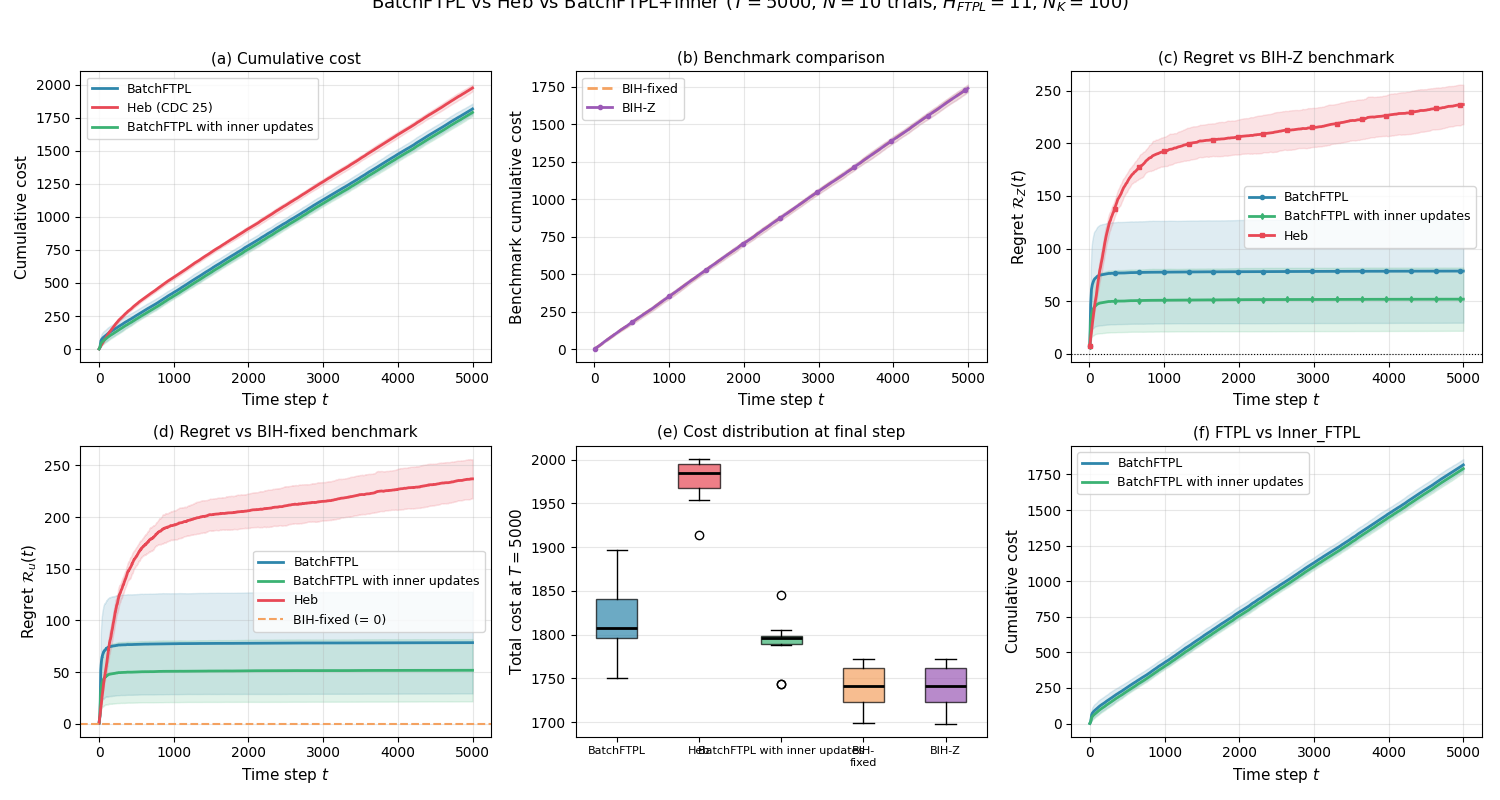

Saved to simulation_results.png


In [45]:
# ── Cell 9: Plotting ──────────────────────────────────────────────────────────

def extract_arrays(results, T):
    N            = len(results)
    ftpl_cumcost = np.zeros((T, N))
    heb_cumcost  = np.zeros((T, N))
    ftpl_inner_cumcost = np.zeros((T, N))
    # dac_cumcost  = np.zeros((T, N))
    bih_fix_cc   = np.zeros((T, N))
    # dac_bm_cc    = np.zeros((T, N))
    bih_z_t      = results[0]['bih_z_t']
    K            = len(bih_z_t)
    bih_z_cc     = np.zeros((K, N))

    for n, r in enumerate(results):
        ftpl_cumcost[:, n] = np.cumsum(r['ftpl_costs'])
        heb_cumcost[:, n]  = np.cumsum(r['heb_costs'])
        ftpl_inner_cumcost[:, n] = np.cumsum(r['ftpl_inner_costs'])
        bih_fix_cc[:, n]   = r['bih_fix_cc']
        bih_z_cc[:, n]     = r['bih_z_cc']

    return (ftpl_cumcost, heb_cumcost, ftpl_inner_cumcost,
            bih_z_t, bih_z_cc, bih_fix_cc
            )


def mean_std(arr):
    return arr.mean(axis=1), arr.std(axis=1)


def plot_ms(ax, x, arr, color, label, alpha=0.15, lw=2,
            marker=None, ms=3, ls='-'):
    mu, sd = mean_std(arr)
    ax.plot(x, mu, color=color, lw=lw, label=label,
            marker=marker, ms=ms, ls=ls,
            markevery=max(1, len(x) // 15))
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=alpha)


# ── Unpack ────────────────────────────────────────────────────────────────────
(ftpl_cumcost, heb_cumcost, ftpl_inner_cumcost,
 bih_z_t, bih_z_cc,
 bih_fix_cc
 ) = extract_arrays(results, T)

t_axis = np.arange(T)

# ── Regret vs BIH-fixed ───────────────────────────────────────────────────────
regret_ftpl_bih_fix = ftpl_cumcost - bih_fix_cc
regret_ftpl_inner_bih_fix = ftpl_inner_cumcost - bih_fix_cc
regret_heb_bih_fix  = heb_cumcost  - bih_fix_cc


# ── Regret vs BIH-Z at checkpoints ───────────────────────────────────────────
ftpl_cc_at_z      = ftpl_cumcost[bih_z_t, :]
ftpl_inner_cc_at_z = ftpl_inner_cumcost[bih_z_t, :]
heb_cc_at_z       = heb_cumcost[bih_z_t, :]
regret_ftpl_bih_z = ftpl_cc_at_z - bih_z_cc
regret_ftpl_inner_bih_z = ftpl_inner_cc_at_z - bih_z_cc
regret_heb_bih_z  = heb_cc_at_z  - bih_z_cc

# ── Colours ───────────────────────────────────────────────────────────────────
C_FTPL   = '#2E86AB'   # blue   — BatchFTPL
C_HEB    = '#E84855'   # red    — Heb (CDC 2025)
C_FTPL_INNER = '#3BB273'   # green — BatchFTPL with inner update
C_BIH_Z  = '#9B59B6'   # purple — BIH-Z benchmark
C_BIH_FX = '#F4A261'   # orange — BIH-fixed benchmark

STYLE = dict(fontsize=11)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.40, wspace=0.32)

# ── (a) Cumulative cost ───────────────────────────────────────────────────────
ax = axes[0, 0]
plot_ms(ax, t_axis, ftpl_cumcost, C_FTPL,   'BatchFTPL')
plot_ms(ax, t_axis, heb_cumcost,  C_HEB,    'Heb (CDC 25)')
plot_ms(ax, t_axis, ftpl_inner_cumcost, C_FTPL_INNER, 'BatchFTPL with inner updates')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel('Cumulative cost', **STYLE)
ax.set_title('(a) Cumulative cost', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (b) Benchmark comparison ──────────────────────────────────────────────────
ax = axes[0, 1]
mu_z, sd_z = mean_std(bih_z_cc)
plot_ms(ax, t_axis, bih_fix_cc, C_BIH_FX, 'BIH-fixed', ls='--')
ax.plot(bih_z_t, mu_z, color=C_BIH_Z, lw=2, label='BIH-Z',
        marker='o', ms=3, markevery=max(1, len(bih_z_t) // 10))
ax.fill_between(bih_z_t, mu_z - sd_z, mu_z + sd_z, color=C_BIH_Z, alpha=0.15)
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel('Benchmark cumulative cost', **STYLE)
ax.set_title('(b) Benchmark comparison', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (c) Regret vs BIH-Z ───────────────────────────────────────────────────────
ax = axes[0, 2]
plot_ms(ax, bih_z_t, regret_ftpl_bih_z, C_FTPL, 'BatchFTPL', marker='o')
plot_ms(ax, bih_z_t, regret_ftpl_inner_bih_z, C_FTPL_INNER, 'BatchFTPL with inner updates', marker='d')
plot_ms(ax, bih_z_t, regret_heb_bih_z,  C_HEB,  'Heb',       marker='s')
ax.axhline(0, color='k', lw=0.8, ls=':')
# t_ref   = bih_z_t[bih_z_t > 0]
# mu_ref  = mean_std(regret_ftpl_bih_z)[0][bih_z_t > 0]
# if mu_ref.mean() > 0:
#     scale_ref = mu_ref.mean() / np.sqrt(t_ref).mean()
#     ax.plot(t_ref, scale_ref * np.sqrt(t_ref), 'k--',
#             lw=1.0, alpha=0.4, label=r'$O(\sqrt{t})$')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel(r'Regret $\mathcal{R}_Z(t)$', **STYLE)
ax.set_title('(c) Regret vs BIH-Z benchmark', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (d) Regret vs BIH-fixed ───────────────────────────────────────────────────
ax = axes[1, 0]
plot_ms(ax, t_axis, regret_ftpl_bih_fix, C_FTPL, 'BatchFTPL')
plot_ms(ax, t_axis, regret_ftpl_inner_bih_fix, C_FTPL_INNER, 'BatchFTPL with inner updates')
plot_ms(ax, t_axis, regret_heb_bih_fix,  C_HEB,  'Heb')
ax.axhline(0, color=C_BIH_FX, lw=1.5, ls='--', label='BIH-fixed (= 0)')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel(r'Regret $\mathcal{R}_u(t)$', **STYLE)
ax.set_title('(d) Regret vs BIH-fixed benchmark', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (f) FTPL vs Inner_FTPL ───────────────────────────────────────────────
ax = axes[1, 2]
plot_ms(ax, t_axis, ftpl_cumcost, C_FTPL,   'BatchFTPL')
# plot_ms(ax, t_axis, heb_cumcost,  C_HEB,    'Heb (CDC 25)')
plot_ms(ax, t_axis, ftpl_inner_cumcost, C_FTPL_INNER, 'BatchFTPL with inner updates')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel('Cumulative cost', **STYLE)
ax.set_title('(f) FTPL vs Inner_FTPL', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (f) Cost distribution box plot ───────────────────────────────────────────
ax = axes[1, 1]
data_box    = [ftpl_cumcost[-1, :], heb_cumcost[-1, :], ftpl_inner_cumcost[-1, :],
               bih_fix_cc[-1, :],   
               bih_z_cc[-1, :]]
colors_box  = [C_FTPL, C_HEB, C_FTPL_INNER,
               C_BIH_FX, 
               C_BIH_Z]
labels_box  = ['BatchFTPL', 'Heb', 'BatchFTPL with inner updates', #'DAC', 
               'BIH-\nfixed',
               'BIH-Z']
bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(data_box) + 1))
ax.set_xticklabels(labels_box, fontsize=8)
ax.set_ylabel(f'Total cost at $T={T}$', **STYLE)
ax.set_title('(e) Cost distribution at final step', **STYLE)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    f'BatchFTPL vs Heb vs BatchFTPL+inner '
    f'($T={T}$, $N={len(results)}$ trials, $H_{{FTPL}}={H_FTPL}$, $N_K={N_K}$)',
    fontsize=13, y=1.01
)

plt.tight_layout()
plt.savefig('simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to simulation_results.png")



In [60]:
print("A =", A)
print("B =", B)
print("x0 =", x0, " U =", U, " W =", W)
print("GAMMA_MIN, KAPPA_MAX =", GAMMA_MIN, KAPPA_MAX)
print("H_FTPL =", H_FTPL, " N_K =", N_K, " len(K_list) =", len(K_list))
print("K0 gamma/kappa =", gamma_K0, kappa_K0)
print("T =", T, " N_trials =", N_trials, " BASE_SEED =", BASE_SEED)
kappas = [c['kappa_K'] for c in K_list]
print("kappa_K range:", min(kappas), max(kappas))

A = [[0.5 0.1 0. ]
 [0.  0.5 0.1]
 [0.1 0.  0.5]]
B = [[0. 1.]
 [0. 0.]
 [1. 0.]]
x0 = [0. 0. 0.]  U = 3.0  W = 0.2
GAMMA_MIN, KAPPA_MAX = 0.2 5.0
H_FTPL = 11  N_K = 100  len(K_list) = 100
K0 gamma/kappa = 0.2765740832431006 1.4483307976632538
T = 5000  N_trials = 15  BASE_SEED = 14
kappa_K range: 1.1674348506965708 1.6276505912645287


In [ ]:
# ── Timing plots (add to cell 9 after the main 6-panel figure) ───────────────
 
def extract_timings(results):
    """
    Pull timing arrays out of results list.
    Returns a dict of {key: (N,) array of per-trial wall times}.
    """
    keys = ['ftpl', 'heb', 'dac', 'bih_z', 'bih_fix', 'phi', 'dac_bm']
    return {k: np.array([r['timings'][k] for r in results]) for k in keys}
 
 
timings = extract_timings(results)
 
# ── Plot A: Algorithm runtimes ────────────────────────────────────────────────
fig_t, axes_t = plt.subplots(1, 2, figsize=(12, 4))
fig_t.subplots_adjust(wspace=0.35)
 
ax = axes_t[0]
 
algo_data   = [timings['ftpl'], timings['heb'], timings['dac']]
algo_labels = ['BatchFTPL', 'Heb', 'DAC']
algo_colors = ['#2E86AB', '#E84855', '#3BB273']
 
bp = ax.boxplot(algo_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', lw=2),
                whiskerprops=dict(lw=1.2),
                capprops=dict(lw=1.2),
                flierprops=dict(marker='o', ms=5, linestyle='none'))
 
for patch, col in zip(bp['boxes'], algo_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
 
for i, (data, col) in enumerate(zip(algo_data, algo_colors), start=1):
    ax.scatter(np.full(len(data), i) + np.random.uniform(-0.12, 0.12, len(data)),
               data, color=col, alpha=0.55, s=20, zorder=5)
 
ax.set_xticks(range(1, len(algo_labels) + 1))
ax.set_xticklabels(algo_labels, fontsize=11)
ax.set_ylabel('Wall time per trial (s)', fontsize=11)
ax.set_title('Algorithm runtimes', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
 
# Annotate with mean ± SD
for i, data in enumerate(algo_data, start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97,
            f'μ={data.mean():.1f}s\nσ={data.std():.1f}s',
            ha='center', va='top', fontsize=8, color='#333333')
 
# ── Plot B: Benchmark runtimes ────────────────────────────────────────────────
ax = axes_t[1]
 
bm_data   = [timings['bih_z'],
             timings['bih_fix'],
             timings['phi'] + timings['dac_bm']]   # total DAC benchmark time
bm_labels = ['BIH-Z', 'BIH-fixed', 'DAC bm\n(Phi+QP)']
bm_colors = ['#9B59B6', '#F4A261', '#555555']
 
bp2 = ax.boxplot(bm_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', lw=2),
                 whiskerprops=dict(lw=1.2),
                 capprops=dict(lw=1.2),
                 flierprops=dict(marker='o', ms=5, linestyle='none'))
 
for patch, col in zip(bp2['boxes'], bm_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
 
for i, (data, col) in enumerate(zip(bm_data, bm_colors), start=1):
    ax.scatter(np.full(len(data), i) + np.random.uniform(-0.12, 0.12, len(data)),
               data, color=col, alpha=0.55, s=20, zorder=5)
 
ax.set_xticks(range(1, len(bm_labels) + 1))
ax.set_xticklabels(bm_labels, fontsize=11)
ax.set_ylabel('Wall time per trial (s)', fontsize=11)
ax.set_title('Benchmark computation runtimes', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
 
for i, data in enumerate(bm_data, start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97,
            f'μ={data.mean():.1f}s\nσ={data.std():.1f}s',
            ha='center', va='top', fontsize=8, color='#333333')
 
# ── Breakdown annotation (printed) ───────────────────────────────────────────
print("\n── Timing breakdown (mean ± std across trials) ──────────────────")
print(f"  BatchFTPL algorithm : {timings['ftpl'].mean():.2f}s ± {timings['ftpl'].std():.2f}s")
print(f"  Heb algorithm       : {timings['heb'].mean():.2f}s ± {timings['heb'].std():.2f}s")
print(f"  DAC algorithm       : {timings['dac'].mean():.2f}s ± {timings['dac'].std():.2f}s")
print()
print(f"  BIH-Z benchmark     : {timings['bih_z'].mean():.2f}s ± {timings['bih_z'].std():.2f}s")
print(f"  BIH-fixed benchmark : {timings['bih_fix'].mean():.2f}s ± {timings['bih_fix'].std():.2f}s")
print(f"  Phi_list compute    : {timings['phi'].mean():.2f}s ± {timings['phi'].std():.2f}s")
print(f"  DAC benchmark QP    : {timings['dac_bm'].mean():.2f}s ± {timings['dac_bm'].std():.2f}s")
print(f"  DAC benchmark total : {(timings['phi']+timings['dac_bm']).mean():.2f}s ± "
      f"{(timings['phi']+timings['dac_bm']).std():.2f}s")
 
fig_t.suptitle(
    f'Runtime breakdown  ($T={T}$, $N={len(results)}$ trials)',
    fontsize=13
)
plt.tight_layout()
plt.savefig('timing_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to timing_results.png")

# Things to be done
- I think DAC now is unltra fast because i exploited the quadratic structure of my cost functions ... Oh wait no i did that only in benchmark computation... The spoeed up now is because of faster matrix projection using SVD approach. 
- But maybe i can exploit the quadratic nbature to speed up BatchFTPL too. The bottleneck is now the cvxpy optimization used in each step. But the solution can be found in closed form.


### Sanity check 
I was initially running the DAC benchmark algorithm to compute the best in hindsight DAC at every time step. But then based on Claudes suggestion I switched to computing the best in hindsight DAC only at the checkpoints every $H_{DAC}$ steps, which is much faster.  To verify that this change doesn't affect the results, I want to now run both versions on a N=10 trial and compared the cumulative costs (averaged across trials) at the checkpoints and in between.The results should be similar with them coinciding exactly at the checkpoints. IF that holds then I shall continue using this much faster benchmark computation. Note that  cumulative costs between checkpoints is obtained by continuing to obtain the DAC control actions using the last checkpoint's best in hindsight DAC.
The following code will be commented out if the results are satisfactory. 

Indeed the results behave very well, there is atmost a 0.5% difference in the value of taken by the benchmark in the two cases for this trial run. So will continue to obtain all my plots with this checkpoint based approach for the DAC benchmark. 

In all honesty, this benchmark exists solely to validate my DAC implementation and as long as that is sub-linear I do not mean to use the DAC benchmark but still. It is helpful to have.

In [48]:
# # ── DAC benchmark: exact vs checkpoint comparison ────────────────────────────
# # Runs T=400, N=10 trials. For each trial, computes the DAC benchmark twice:
# #   1. Exact:      solve_every=1  (QP at every time step)
# #   2. Checkpoint: solve_every=H_DAC//2  (QP at every H_DAC/2 steps)
# # Plots the mean ± std across trials for both, plus the approximation error.
# # All other variables (A, B, K0, DIM_X, DIM_U, H_DAC, kappa_K0, gamma_K0,
# # kappa_B, W, sample_trial_data, compute_xd_sequence, compute_Phi_list,
# # compute_dac_cumcost) are assumed to be in scope from earlier cells.

# T_cmp         = 400
# N_cmp         = 3
# SEED_CMP      = 99
# solve_every_cmp = max(1, H_DAC // 2)
# A_K0_cmp      = A - B @ K0

# print(f"T={T_cmp},  H_DAC={H_DAC},  solve_every={solve_every_cmp}")
# print(f"Exact solves per trial    : {T_cmp - 2}")
# print(f"Checkpoint solves per trial: {len(range(2, T_cmp, solve_every_cmp)) + 1}")
# print()

# exact_cc_list = []
# ckpt_cc_list  = []
# t_exact_list  = []
# t_ckpt_list   = []

# for trial in range(N_cmp):
#     rng_t = np.random.default_rng(SEED_CMP + trial)
#     Q_t, c_t, w_t = sample_trial_data(T_cmp, DIM_X, DIM_U, W, rng_t)
#     x_d_t  = compute_xd_sequence(w_t, A_K0_cmp, T_cmp)
#     bc_t   = c_t - x_d_t
#     Phi_t  = compute_Phi_list(w_t, A, B, DIM_X, DIM_U, H_DAC, T_cmp)

#     # ── Exact ─────────────────────────────────────────────────────────────────
#     t0 = time.time()
#     cc_exact = compute_dac_cumcost(Q_t, bc_t, Phi_t, DIM_U, DIM_X, H_DAC,
#                                     kappa_K0, gamma_K0, kappa_B, solve_every=1)
#     t_e = time.time() - t0

#     # ── Checkpoint ────────────────────────────────────────────────────────────
#     t0 = time.time()
#     cc_ckpt  = compute_dac_cumcost(Q_t, bc_t, Phi_t, DIM_U, DIM_X, H_DAC,
#                                     kappa_K0, gamma_K0, kappa_B,
#                                     solve_every=solve_every_cmp)
#     t_c = time.time() - t0

#     exact_cc_list.append(cc_exact)
#     ckpt_cc_list.append(cc_ckpt)
#     t_exact_list.append(t_e)
#     t_ckpt_list.append(t_c)

#     print(f"  trial {trial+1:2d}: exact {t_e:5.1f}s   checkpoint {t_c:5.1f}s   "
#           f"speedup {t_e/max(t_c, 1e-9):5.1f}x")

# exact_arr = np.array(exact_cc_list)   # (N_cmp, T_cmp)
# ckpt_arr  = np.array(ckpt_cc_list)    # (N_cmp, T_cmp)

# mean_speedup = np.mean(np.array(t_exact_list) / np.maximum(t_ckpt_list, 1e-9))
# print(f"\nMean speedup: {mean_speedup:.1f}x")

# # ── Plot ──────────────────────────────────────────────────────────────────────
# t_axis_cmp = np.arange(T_cmp)

# fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(13, 4.5))

# # ── Left: cumulative cost — both approaches ───────────────────────────────────
# ax = axes_cmp[0]

# mu_e, sd_e = exact_arr.mean(axis=0), exact_arr.std(axis=0)
# mu_c, sd_c = ckpt_arr.mean(axis=0),  ckpt_arr.std(axis=0)

# ax.plot(t_axis_cmp, mu_e, color='#2E86AB', lw=2,
#         label=f'Exact (solve every step)')
# ax.fill_between(t_axis_cmp, mu_e - sd_e, mu_e + sd_e,
#                 color='#2E86AB', alpha=0.15)

# ax.plot(t_axis_cmp, mu_c, color='#E84855', lw=2, ls='--',
#         label=f'Checkpoint (every {solve_every_cmp} steps)')
# ax.fill_between(t_axis_cmp, mu_c - sd_c, mu_c + sd_c,
#                 color='#E84855', alpha=0.15)

# ax.set_xlabel('Time step $t$', fontsize=11)
# ax.set_ylabel('DAC benchmark cumulative cost', fontsize=11)
# ax.set_title('DAC benchmark: exact vs checkpoint', fontsize=12)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# # ── Right: approximation error (checkpoint − exact) ───────────────────────────
# ax = axes_cmp[1]

# diff     = ckpt_arr - exact_arr          # positive = checkpoint overestimates
# mu_d     = diff.mean(axis=0)
# sd_d     = diff.std(axis=0)
# rel_err  = np.abs(mu_d) / np.maximum(np.abs(mu_e), 1e-9) * 100   # % error

# ax.plot(t_axis_cmp, mu_d, color='#3BB273', lw=2, label='Mean difference')
# ax.fill_between(t_axis_cmp, mu_d - sd_d, mu_d + sd_d,
#                 color='#3BB273', alpha=0.15)
# ax.axhline(0, color='k', lw=0.8, ls=':')

# # Second y-axis: relative error in %
# ax2 = ax.twinx()
# ax2.plot(t_axis_cmp, rel_err, color='#F4A261', lw=1.2, ls=':', alpha=0.7,
#          label='Relative error (%)')
# ax2.set_ylabel('Relative error (%)', fontsize=10, color='#F4A261')
# ax2.tick_params(axis='y', labelcolor='#F4A261')

# ax.set_xlabel('Time step $t$', fontsize=11)
# ax.set_ylabel('Checkpoint − Exact', fontsize=11)
# ax.set_title(f'Approximation error  (mean speedup {mean_speedup:.1f}×)', fontsize=12)

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
# ax.grid(True, alpha=0.3)

# fig_cmp.suptitle(
#     f'DAC benchmark approximation  '
#     f'($T={T_cmp}$, $N={N_cmp}$ trials, '
#     f'$H_{{DAC}}={H_DAC}$, solve_every={solve_every_cmp})',
#     fontsize=12, y=1.02
# )

# plt.tight_layout()
# plt.savefig('dac_benchmark_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved to dac_benchmark_comparison.png")